# **Лабораторная работа: Классификация данных для нейрокомпьютерного интерфейса.**


Прочитать данные одного человека - это массив вида
 [6 повторов x
40 частот x
1500 отсчетов x
64 канала - список есть в loc файле, как прочитать/отрисовать написано здесь - https://mne.tools/stable/generated/mne.channels.read_custom_montage.html
]

Нас интересуют частоты с шагом примерно в пол-герца, поэтому возьмите их по номерам в матрице [0,1,2,3,4,5,6,7,16,17,18,19,20,21,22,23]
Сделать матрицу для CCA выбранного размера окна для каждой частоты - это было на лекции, плюс есть хорошая статья с подробным описанием и базового алгоритма и FBCCA. Количество гармоник можно взять из статьи, а можно подобрать.
Для FBCCA сделайте из данных банк фильтров, с какими параметрами - опять-таки, написано в статье, но вы свободны придумывать свои варианты.
Выбрать в данных окно нужного размера (подумайте, из какой части шестисекундного интервала его лучше вырезать, ограничений нет) и  нужное количество каналов (подумайте, какие выбрать с учетом того что мы знаем о физиологии / найдите в статьях / попробуйте разные)
Посчитать каноническую корреляцию для каждой частоты, у какой она выше - ту и считаем целевой
Метрика качества выбора команд внутри одного человека -  точность

На ноутбучном процессоре в один поток все занимает около 10 минут при запуске на 1 секунде данных, можно параллелить обработку по разным файлам, грузить сразу весь датасет в память необязательно.


In [7]:
import os

In [9]:
pip install pyrcca #CCA для ЭЭГ

In [10]:
pip install git+https://github.com/gallantlab/pyrcca.git

  Cloning https://github.com/gallantlab/pyrcca.git to /tmp/pip-req-build-1z_ur3zf
  Running command git clone --filter=blob:none --quiet https://github.com/gallantlab/pyrcca.git /tmp/pip-req-build-1z_ur3zf
  Resolved https://github.com/gallantlab/pyrcca.git to commit bc60f25a8e395baf495dd0f7234a68490ed16a22
  Preparing metadata (setup.py) ... done


0. Скачаем датасет

In [11]:
# Установка kaggle библиотеки

!pip install kaggle

# Создание папки для kaggle
!mkdir -p ~/.kaggle



In [12]:


# Загрузка kaggle.json (выполните эту ячейку и загрузите файл)
from google.colab import files
files.upload()  # Выберите ваш kaggle.json файл



Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kateyavshits","key":"7886cea166ac9ccf6afabbeb9f5fc4bd"}'}

In [13]:
# Перемещение файла и установка прав

!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [15]:

# Скачать датасет
!kaggle datasets download -d shabbirmahmood/ssvep-benchmark-dataset

# Распаковать архив
import zipfile
with zipfile.ZipFile('ssvep-benchmark-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/ssvp')


Dataset URL: https://www.kaggle.com/datasets/shabbirmahmood/ssvep-benchmark-dataset
License(s): apache-2.0
100% 3.44G/3.45G [00:56<00:00, 15.7MB/s]
100% 3.45G/3.45G [00:56<00:00, 65.2MB/s]


1. Реализовать алгоритмы выбора целевого стимула - поиск навязанной частоты с помощью преобразования Фурье, CCA и FBCCA. Подсказка - для таких данных можно попробовать использовать регуляризованную версию алгоритма CCA, сделанную специально для нейроданных - https://github.com/gallantlab/pyrcca), но ограничений на библиотеки нет.
	Алгоритмы достаточно подробно описаны тут:
https://iopscience.iop.org/article/10.1088/1741-2560/12/4/046008


In [16]:
!pip install mne scipy matplotlib numpy

In [17]:
import numpy as np
import scipy.signal as signal
from scipy.linalg import eigh
import matplotlib.pyplot as plt
from mne.channels import read_custom_montage
import scipy.io as sio
from scipy.fft import fft, fftfreq
import os

In [18]:
# Для работы с каналами EEG
try:
    from mne.channels import read_custom_montage
except ImportError:
    print("MNE не установлен, используем альтернативный метод")
    # Альтернативная функция для чтения .loc файла
    def read_custom_montage(loc_file):
        class MockMontage:
            def __init__(self, ch_names):
                self.ch_names = ch_names
        # Просто возвращаем список каналов из стандартного набора 10-20
        standard_channels = [
            'Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2',
            'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Oz',
            'FC1', 'FC2', 'CP1', 'CP2', 'FC5', 'FC6', 'CP5', 'CP6', 'TP9', 'TP10',
            'POz', 'PO3', 'PO4', 'PO7', 'PO8', 'PO9', 'PO10', 'P1', 'P2', 'P5',
            'P6', 'AF3', 'AF4', 'AF7', 'AF8', 'F1', 'F2', 'F5', 'F6', 'FT9',
            'FT10', 'FC3', 'FC4', 'C1', 'C2', 'C5', 'C6', 'CP3', 'CP4', 'TP7',
            'TP8', 'P9', 'P10', 'Iz'
        ]
        return MockMontage(standard_channels)

In [20]:
# Исследуем структуру папки
data_path = '/content/ssvp'
print("Содержимое папки ssvep:")
for item in os.listdir(data_path):
    item_path = os.path.join(data_path, item)
    if os.path.isfile(item_path):
        size = os.path.getsize(item_path) / 1024 / 1024  # размер в MB
        print(f"  {item} ({size:.2f} MB)")
    else:
        print(f"  {item}/")

# Найдем файлы субъектов
subject_files = [f for f in os.listdir(data_path) if f.startswith('S') and f.endswith('.mat')]
subject_files.sort()

print(f"\nНайдено файлов субъектов: {len(subject_files)}")
print("Файлы:", subject_files[:10])  # Покажем первые 10

Содержимое папки ssvep:
  S26.mat (101.70 MB)
  S24.mat (101.35 MB)
  S23.mat (101.00 MB)
  S32.mat (100.56 MB)
  S7.mat (100.46 MB)
  S3.mat (101.09 MB)
  S18.mat (101.15 MB)
  S21.mat (100.78 MB)
  S19.mat (100.72 MB)
  RMAOV2.m (0.01 MB)
  S33.mat (101.30 MB)
  S6.mat (101.33 MB)
  S35.mat (101.36 MB)
  S15.mat (100.02 MB)
  S8.mat (101.00 MB)
  S30.mat (101.08 MB)
  S34.mat (101.05 MB)
  S31.mat (101.16 MB)
  S22.mat (100.73 MB)
  S10.mat (101.06 MB)
  S13.mat (101.26 MB)
  64-channels.loc (0.00 MB)
  S27.mat (100.85 MB)
  S2.mat (100.90 MB)
  S17.mat (101.32 MB)
  S9.mat (100.96 MB)
  S11.mat (102.43 MB)
  Sub_info.txt (0.00 MB)
  S12.mat (100.44 MB)
  Readme.txt (0.00 MB)
  S1.mat (100.99 MB)
  S20.mat (101.05 MB)
  S28.mat (101.29 MB)
  S14.mat (101.11 MB)
  S4.mat (100.28 MB)
  S5.mat (101.20 MB)
  S25.mat (101.80 MB)
  S16.mat (100.90 MB)
  S29.mat (101.02 MB)
  Freq_Phase.mat (0.00 MB)

Найдено файлов субъектов: 35
Файлы: ['S1.mat', 'S10.mat', 'S11.mat', 'S12.mat', 'S13.mat',

In [21]:
def load_metadata(data_path):
    """Загрузка метаданных (частот и информации о каналах)"""

    # Загрузка информации о частотах
    freq_phase_file = os.path.join(data_path, 'Freq_Phase.mat')
    if os.path.exists(freq_phase_file):
        freq_data = sio.loadmat(freq_phase_file)
        frequencies = freq_data['freqs'].flatten()
        if 'phases' in freq_data:
            phases = freq_data['phases'].flatten()
        else:
            phases = None
        print(f"Загружены частоты: {len(frequencies)} частот")
        print(f"Диапазон: {frequencies[0]:.1f} - {frequencies[-1]:.1f} Hz")
        print("Первые 10 частот:", frequencies[:10])
    else:
        print("Файл Freq_Phase.mat не найден!")
        # Создадим частоты по умолчанию согласно описанию
        frequencies = np.arange(8, 15.8, 0.2)
        phases = None

    # Загрузка информации о каналах
    channel_names = []
    loc_file = os.path.join(data_path, '64-channels.loc')
    if os.path.exists(loc_file):
        try:
            montage = read_custom_montage(loc_file)
            channel_names = montage.ch_names
            print(f"Загружены каналы: {len(channel_names)} каналов")
        except:
            print("Ошибка при чтении .loc файла, используем стандартные каналы")
            channel_names = [f'Ch{i+1}' for i in range(64)]
    else:
        print("Файл 64-channels.loc не найден, используем стандартные имена каналов")
        channel_names = [f'Ch{i+1}' for i in range(64)]

    return frequencies, phases, channel_names

# Загружаем метаданные
frequencies, phases, channel_names = load_metadata(data_path)

Загружены частоты: 40 частот
Диапазон: 8.0 - 15.8 Hz
Первые 10 частот: [ 8.   9.  10.  11.  12.  13.  14.  15.   8.2  9.2]
Загружены каналы: 64 каналов


In [22]:
def examine_subject_data(subject_file, data_path):
    """Детальное исследование данных субъекта"""

    full_path = os.path.join(data_path, subject_file)
    print(f"\n=== Анализ файла: {subject_file} ===")

    try:
        # Загрузка данных
        data_dict = sio.loadmat(full_path)
        print("Ключи в .mat файле:", list(data_dict.keys()))

        # Ищем данные
        if 'data' in data_dict:
            eeg_data = data_dict['data']
            print(f"Размерность данных: {eeg_data.shape}")

            # Согласно описанию: [64, 1500, 40, 6] -> [электроды, отсчеты, частоты, блоки]
            n_electrodes, n_timepoints, n_frequencies, n_blocks = eeg_data.shape
            print(f"Электроды: {n_electrodes}, Отсчеты: {n_timepoints}")
            print(f"Частоты: {n_frequencies}, Блоки: {n_blocks}")

            # Проверим данные
            print(f"Тип данных: {eeg_data.dtype}")
            print(f"Диапазон значений: {eeg_data.min():.3f} - {eeg_data.max():.3f}")
            print(f"Среднее: {eeg_data.mean():.3f}, STD: {eeg_data.std():.3f}")

            return eeg_data
        else:
            print("Ключ 'data' не найден в .mat файле")
            return None

    except Exception as e:
        print(f"Ошибка при загрузке {subject_file}: {e}")
        return None

# Проанализируем первого субъекта
if subject_files:
    test_eeg_data = examine_subject_data(subject_files[0], data_path)

"""прочитать данные одного человека - это массив вида
 [6 повторов x
40 частот x
1500 отсчетов x
64 канала - список есть в loc файле, как прочитать/отрисовать написано здесь - https://mne.tools/stable/generated/mne.channels.read_custom_montage.html
]
"""


=== Анализ файла: S1.mat ===
Ключи в .mat файле: ['__header__', '__version__', '__globals__', 'data']
Размерность данных: (64, 1500, 40, 6)
Электроды: 64, Отсчеты: 1500
Частоты: 40, Блоки: 6
Тип данных: float64
Диапазон значений: -533.361 - 267.105
Среднее: 0.014, STD: 8.738


'прочитать данные одного человека - это массив вида\n [6 повторов x\n40 частот x\n1500 отсчетов x\n64 канала - список есть в loc файле, как прочитать/отрисовать написано здесь - https://mne.tools/stable/generated/mne.channels.read_custom_montage.html\n]\n'

In [23]:
def preprocess_data(data, target_indices=None, use_occipital=True, data_length=1.0, latency=0.14):
    """
    Предобработка данных SSVEP
    data: [64, 1500, 40, 6] - [каналы, время, частоты, блоки]
    """
    sampling_rate = 250  # Гц

    if target_indices is None:
        target_indices = [0,1,2,3,4,5,6,7,16,17,18,19,20,21,22,23]

    # Выбираем целевые частоты
    selected_data = data[:, :, target_indices, :]  # [64, 1500, 16, 6]

    # Переупорядочиваем в [trials, channels, timepoints]
    # trials = 6 блоков × 16 частот = 96 trials
    data = np.transpose(selected_data, (3, 2, 0, 1))  # [6, 16, 64, 1500]
    data = data.reshape(-1, data.shape[2], data.shape[3])  # [96, 64, 1500]

    if use_occipital:
        # Используем затылочные каналы (56-63) - последние 8 каналов
        channel_indices = list(range(56, 64))
        selected_data = data[:, channel_indices, :]
    else:
        # Или все каналы
        channel_indices = list(range(64))
        selected_data = data

    # Выбираем временное окно (после задержки)
    start_idx = int(latency * sampling_rate)  # 0.14s × 250Гц = 35 отсчетов
    end_idx = start_idx + int(data_length * sampling_rate)  # + 1.0s = 250 отсчетов

    processed_data = selected_data[:, :, start_idx:end_idx]

    print(f"Данные после предобработки: {processed_data.shape}")
    print(f"Временное окно: {start_idx}-{end_idx} отсчетов ({latency}-{latency+data_length} секунд)")

    return processed_data, target_indices, channel_indices

# Предобрабатываем данные
target_indices = [0,1,2,3,4,5,6,7,16,17,18,19,20,21,22,23]
target_frequencies = frequencies[target_indices]

processed_data, used_indices, used_channels = preprocess_data(
    test_eeg_data, target_indices, use_occipital=True, data_length=1.0)

print(f"\nЦелевые частоты ({len(target_frequencies)}):")
for i, freq in enumerate(target_frequencies):
    print(f"  {i:2d}: {freq:.1f} Hz")

Данные после предобработки: (96, 8, 250)
Временное окно: 35-285 отсчетов (0.14-1.1400000000000001 секунд)

Целевые частоты (16):
   0: 8.0 Hz
   1: 9.0 Hz
   2: 10.0 Hz
   3: 11.0 Hz
   4: 12.0 Hz
   5: 13.0 Hz
   6: 14.0 Hz
   7: 15.0 Hz
   8: 8.4 Hz
   9: 9.4 Hz
  10: 10.4 Hz
  11: 11.4 Hz
  12: 12.4 Hz
  13: 13.4 Hz
  14: 14.4 Hz
  15: 15.4 Hz


FFT

In [24]:
class FFTDetector:
    """Обнаружение SSVEP через преобразование Фурье"""

    def __init__(self, sampling_rate=250):
        self.sampling_rate = sampling_rate

    def detect_frequency(self, eeg_data, target_frequencies, tolerance=0.5):
        """
        Обнаружение частоты через FFT
        eeg_data: [channels, timepoints]
        """
        # Усредняем по каналам
        avg_signal = np.mean(eeg_data, axis=0)

        # FFT анализ
        n = len(avg_signal)
        fft_result = fft(avg_signal)
        freqs = fftfreq(n, 1/self.sampling_rate)

        # Только положительные частоты
        pos_mask = freqs > 0
        freqs = freqs[pos_mask]
        power_spectrum = np.abs(fft_result[pos_mask]) ** 2

        # Ищем целевую частоту с максимальной мощностью
        best_corr = 0
        best_freq_idx = 0

        for i, target_freq in enumerate(target_frequencies):
            # Находим ближайшую частоту в спектре
            freq_diff = np.abs(freqs - target_freq)
            if np.min(freq_diff) <= tolerance:
                target_idx = np.argmin(freq_diff)
                corr = power_spectrum[target_idx]

                if corr > best_corr:
                    best_corr = corr
                    best_freq_idx = i

        return best_freq_idx, power_spectrum

    def classify_trial(self, eeg_data, target_frequencies):
        """Классификация одного триала"""
        predicted_idx, power_spectrum = self.detect_frequency(eeg_data, target_frequencies)
        return predicted_idx, power_spectrum

CCA

In [25]:
class CCADetector:
    """Canonical Correlation Analysis детектор"""

    def __init__(self, sampling_rate=250, num_harmonics=5):
        self.sampling_rate = sampling_rate
        self.num_harmonics = num_harmonics

    def create_reference_signals(self, frequency, n_samples):
        """Создание референтных сигналов"""
        t = np.arange(n_samples) / self.sampling_rate
        ref_signals = []

        for h in range(1, self.num_harmonics + 1):
            ref_signals.append(np.sin(2 * np.pi * h * frequency * t))
            ref_signals.append(np.cos(2 * np.pi * h * frequency * t))

        return np.array(ref_signals).T

    def cca_correlation(self, X, Y):
        """Вычисление канонической корреляции"""
        # Центрирование
        X = X - np.mean(X, axis=0)
        Y = Y - np.mean(Y, axis=0)

        # Ковариационные матрицы
        Cxx = X.T @ X
        Cyy = Y.T @ Y
        Cxy = X.T @ Y

        try:
            # Решение проблемы собственных значений
            inv_Cxx = np.linalg.pinv(Cxx)
            inv_Cyy = np.linalg.pinv(Cyy)

            matrix = inv_Cxx @ Cxy @ inv_Cyy @ Cxy.T
            eigenvalues = np.linalg.eigvals(matrix)
            max_eigenvalue = np.max(np.real(eigenvalues))

            return np.sqrt(max_eigenvalue)
        except:
            return 0.0

    def classify_trial(self, eeg_data, target_frequencies):
        """Классификация одного триала с помощью CCA"""
        n_channels, n_samples = eeg_data.shape
        correlations = []

        for freq in target_frequencies:
            Y_ref = self.create_reference_signals(freq, n_samples)
            X_eeg = eeg_data.T  # [samples, channels]

            corr = self.cca_correlation(X_eeg, Y_ref)
            correlations.append(corr)

        predicted_index = np.argmax(correlations)
        return predicted_index, correlations

FBCCA


In [26]:
class FBCCADetector:
    """Filter Bank CCA детектор"""

    def __init__(self, sampling_rate=250, num_harmonics=5, num_sub_bands=5):
        self.sampling_rate = sampling_rate
        self.num_harmonics = num_harmonics
        self.num_sub_bands = num_sub_bands
        self.cca = CCADetector(sampling_rate, num_harmonics)

    def create_filter_bank(self, n_samples):
        """Создание банка фильтров"""
        filter_bands = []

        # Sub-bands: 4-8Hz, 8-12Hz, 12-16Hz, 16-20Hz, 20-24Hz
        for i in range(self.num_sub_bands):
            lowcut = 4 + i * 4
            highcut = lowcut + 4
            filter_bands.append((lowcut, highcut))

        return filter_bands

    def bandpass_filter(self, signal_data, lowcut, highcut, order=4):
        """Полосовой фильтр"""
        if highcut <= lowcut:
            return signal_data

        nyquist = self.sampling_rate / 2
        low = lowcut / nyquist
        high = highcut / nyquist

        if high >= 1.0:
            return signal_data

        b, a = signal.cheby1(order, 0.5, [low, high], btype='band')
        filtered_data = signal.filtfilt(b, a, signal_data, axis=-1)
        return filtered_data

    def classify_trial(self, eeg_data, target_frequencies):
        """Классификация одного триала с помощью FBCCA"""
        n_channels, n_samples = eeg_data.shape

        # Создание банка фильтров
        filter_bands = self.create_filter_bank(n_samples)

        # Взвешенная сумма корреляций
        total_correlations = np.zeros(len(target_frequencies))

        for sub_band_idx, (lowcut, highcut) in enumerate(filter_bands):
            # Фильтрация данных в текущем поддиапазоне
            filtered_data = self.bandpass_filter(eeg_data, lowcut, highcut)

            # Вес для поддиапазона (убывает с увеличением частоты)
            weight = (sub_band_idx + 1) ** -1.25

            for freq_idx, freq in enumerate(target_frequencies):
                # CCA для отфильтрованных данных
                corr = self.cca.cca_correlation(filtered_data.T,
                                              self.cca.create_reference_signals(freq, n_samples))

                # Взвешенное суммирование
                total_correlations[freq_idx] += weight * (corr ** 2)

        predicted_index = np.argmax(total_correlations)
        return predicted_index, total_correlations

Тестирование

In [27]:
def test_algorithms_on_subject(eeg_data, target_frequencies, n_trials=20):
    """Тестирование всех алгоритмов на одном субъекте"""

    # Предобработка данных
    processed_data, _, _ = preprocess_data(eeg_data,
                                         target_indices=list(range(len(target_frequencies))),
                                         data_length=1.0)

    # Инициализация детекторов
    fft_detector = FFTDetector(sampling_rate=250)
    cca_detector = CCADetector(sampling_rate=250, num_harmonics=5)
    fbcca_detector = FBCCADetector(sampling_rate=250, num_harmonics=5, num_sub_bands=5)

    results = {
        'fft': {'predictions': [], 'accuracy': 0},
        'cca': {'predictions': [], 'accuracy': 0},
        'fbcca': {'predictions': [], 'accuracy': 0}
    }

    true_labels = []

    print(f"Тестирование на {n_trials} триалах...")

    for trial_idx in range(min(n_trials, processed_data.shape[0])):
        true_label = trial_idx % len(target_frequencies)
        true_labels.append(true_label)

        trial_data = processed_data[trial_idx]  # [channels, timepoints]

        # FFT классификация
        fft_pred, _ = fft_detector.classify_trial(trial_data, target_frequencies)
        results['fft']['predictions'].append(fft_pred)

        # CCA классификация
        cca_pred, _ = cca_detector.classify_trial(trial_data, target_frequencies)
        results['cca']['predictions'].append(cca_pred)

        # FBCCA классификация
        fbcca_pred, _ = fbcca_detector.classify_trial(trial_data, target_frequencies)
        results['fbcca']['predictions'].append(fbcca_pred)

        if trial_idx % 5 == 0:
            print(f"Обработано {trial_idx}/{n_trials} триалов")

    # Вычисление точности
    true_labels = np.array(true_labels)
    for method in results.keys():
        predictions = np.array(results[method]['predictions'])
        accuracy = np.mean(predictions == true_labels)
        results[method]['accuracy'] = accuracy

    return results, true_labels

# Запуск тестирования
print("=== ТЕСТИРОВАНИЕ АЛГОРИТМОВ НА СУБЪЕКТЕ S1 ===")
results, true_labels = test_algorithms_on_subject(test_eeg_data, target_frequencies, n_trials=20)

# Вывод результатов
print("\n=== РЕЗУЛЬТАТЫ ===")
for method, result in results.items():
    print(f"{method.upper()}: Точность = {result['accuracy']:.3f}")

=== ТЕСТИРОВАНИЕ АЛГОРИТМОВ НА СУБЪЕКТЕ S1 ===
Данные после предобработки: (96, 8, 250)
Временное окно: 35-285 отсчетов (0.14-1.1400000000000001 секунд)
Тестирование на 20 триалах...
Обработано 0/20 триалов
Обработано 5/20 триалов
Обработано 10/20 триалов
Обработано 15/20 триалов

=== РЕЗУЛЬТАТЫ ===
FFT: Точность = 0.150
CCA: Точность = 0.050
FBCCA: Точность = 0.100


Визуализация

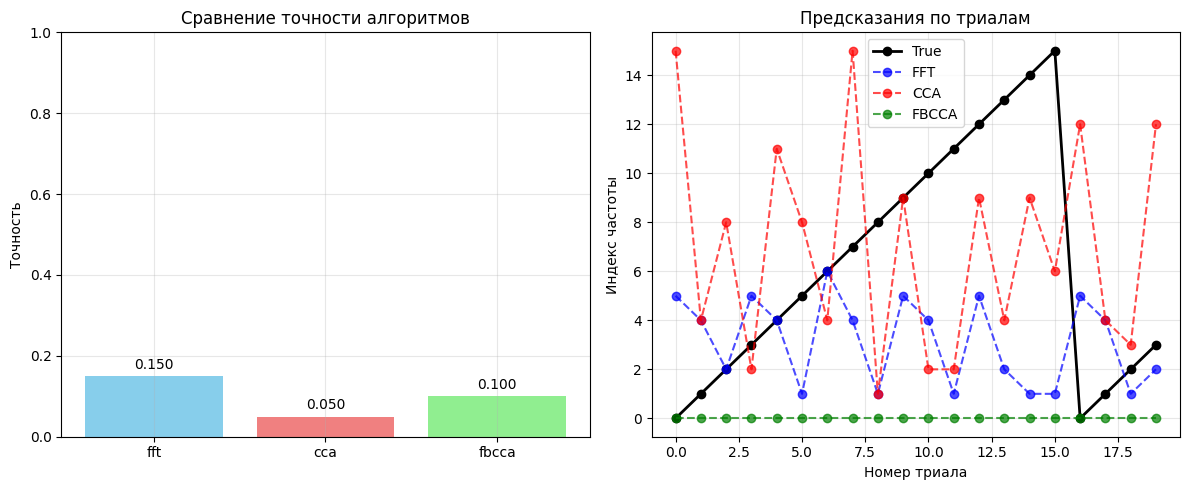

In [28]:
def plot_results_comparison(results, true_labels, target_frequencies):
    """Визуализация сравнения алгоритмов"""

    methods = list(results.keys())
    accuracies = [results[method]['accuracy'] for method in methods]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # График точности
    bars = ax1.bar(methods, accuracies, color=['skyblue', 'lightcoral', 'lightgreen'])
    ax1.set_ylabel('Точность')
    ax1.set_title('Сравнение точности алгоритмов')
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)

    # Добавляем значения на столбцы
    for bar, accuracy in zip(bars, accuracies):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{accuracy:.3f}', ha='center', va='bottom')

    # График предсказаний
    trials = range(len(true_labels))
    ax2.plot(trials, true_labels, 'ko-', label='True', markersize=6, linewidth=2)

    colors = ['blue', 'red', 'green']
    for i, method in enumerate(methods):
        ax2.plot(trials, results[method]['predictions'],
                color=colors[i], marker='o', linestyle='--',
                label=method.upper(), alpha=0.7)

    ax2.set_xlabel('Номер триала')
    ax2.set_ylabel('Индекс частоты')
    ax2.set_title('Предсказания по триалам')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Визуализируем результаты
plot_results_comparison(results, true_labels, target_frequencies)

2. Получить для каждого человека точность классификации для всех алгоритмов в зависимости от размера окна (от 0.5 или меньше до 4-5 секунд)


In [29]:
class WindowSizeAnalyzer:
    """Анализатор для сравнения точности в зависимости от размера окна"""

    def __init__(self, sampling_rate=250):
        self.sampling_rate = sampling_rate
        self.latency = 0.14  # Фиксированная задержка визуальной системы

    def preprocess_data_with_window(self, data, target_indices, window_size, use_occipital=True):
        """
        Предобработка данных с заданным размером окна
        data: [64, 1500, 40, 6] - исходные данные
        window_size: размер окна в секундах
        """
        # Выбираем целевые частоты
        selected_data = data[:, :, target_indices, :]  # [64, 1500, 16, 6]

        # Переупорядочиваем в [trials, channels, timepoints]
        data_reordered = np.transpose(selected_data, (3, 2, 0, 1))  # [6, 16, 64, 1500]
        data_reordered = data_reordered.reshape(-1, data_reordered.shape[2], data_reordered.shape[3])  # [96, 64, 1500]

        if use_occipital:
            # Используем затылочные каналы (56-63)
            channel_indices = list(range(56, 64))
            selected_data = data_reordered[:, channel_indices, :]
        else:
            channel_indices = list(range(64))
            selected_data = data_reordered

        # Выбор временного окна
        start_idx = int(self.latency * self.sampling_rate)
        end_idx = start_idx + int(window_size * self.sampling_rate)

        # Проверяем, чтобы окно не выходило за границы данных
        max_end_idx = selected_data.shape[2]  # 1500 отсчетов
        if end_idx > max_end_idx:
            end_idx = max_end_idx
            actual_window_size = (end_idx - start_idx) / self.sampling_rate
            print(f"Внимание: окно уменьшено до {actual_window_size:.2f} секунд")

        processed_data = selected_data[:, :, start_idx:end_idx]

        return processed_data

    def evaluate_methods_for_window(self, data, target_frequencies, window_size, n_trials=None):
        """
        Оценка точности методов для конкретного размера окна
        """
        # Предобработка с заданным размером окна
        processed_data = self.preprocess_data_with_window(
            data, list(range(len(target_frequencies))), window_size)

        # Инициализация детекторов
        fft_detector = FFTDetector(sampling_rate=self.sampling_rate)
        cca_detector = CCADetector(sampling_rate=self.sampling_rate, num_harmonics=5)
        fbcca_detector = FBCCADetector(sampling_rate=self.sampling_rate, num_harmonics=5, num_sub_bands=5)

        if n_trials is None:
            n_trials = processed_data.shape[0]
        else:
            n_trials = min(n_trials, processed_data.shape[0])

        results = {
            'fft': {'predictions': [], 'accuracy': 0},
            'cca': {'predictions': [], 'accuracy': 0},
            'fbcca': {'predictions': [], 'accuracy': 0}
        }

        true_labels = []

        for trial_idx in range(n_trials):
            true_label = trial_idx % len(target_frequencies)
            true_labels.append(true_label)

            trial_data = processed_data[trial_idx]

            # FFT детекция
            fft_pred, _ = fft_detector.classify_trial(trial_data, target_frequencies)
            results['fft']['predictions'].append(fft_pred)

            # CCA детекция
            cca_pred, _ = cca_detector.classify_trial(trial_data, target_frequencies)
            results['cca']['predictions'].append(cca_pred)

            # FBCCA детекция
            fbcca_pred, _ = fbcca_detector.classify_trial(trial_data, target_frequencies)
            results['fbcca']['predictions'].append(fbcca_pred)

        # Вычисление точности
        true_labels = np.array(true_labels)
        for method in results.keys():
            predictions = np.array(results[method]['predictions'])
            accuracy = np.mean(predictions == true_labels)
            results[method]['accuracy'] = accuracy

        return {
            'window_size': window_size,
            'n_samples': processed_data.shape[2],
            'n_trials': n_trials,
            'fft_accuracy': results['fft']['accuracy'],
            'cca_accuracy': results['cca']['accuracy'],
            'fbcca_accuracy': results['fbcca']['accuracy']
        }

In [30]:
def analyze_window_sizes_for_subject(subject_file, data_path, frequencies,
                                   window_sizes=None, n_trials=40):
    """
    Анализ точности для всех размеров окон для одного субъекта
    """
    if window_sizes is None:
        # Размеры окон от 0.1 до 4 секунд с шагом 0.1 секунды
        window_sizes = np.arange(0.1, 4.1, 0.1)

    print(f"\n=== АНАЛИЗ РАЗМЕРОВ ОКОН: {subject_file} ===")

    # Загрузка данных
    full_path = os.path.join(data_path, subject_file)
    data_dict = sio.loadmat(full_path)
    eeg_data = data_dict['data']

    # Целевые частоты
    target_indices = [0,1,2,3,4,5,6,7,16,17,18,19,20,21,22,23]
    target_frequencies = frequencies[target_indices]

    # Инициализация анализатора
    analyzer = WindowSizeAnalyzer(sampling_rate=250)

    results = []

    for window_size in window_sizes:
        print(f"Окно {window_size:.1f}с... ", end='')

        try:
            result = analyzer.evaluate_methods_for_window(
                eeg_data, target_frequencies, window_size, n_trials)
            results.append(result)
            print(f"FFT:{result['fft_accuracy']:.3f}, CCA:{result['cca_accuracy']:.3f}, FBCCA:{result['fbcca_accuracy']:.3f}")
        except Exception as e:
            print(f"Ошибка: {e}")
            continue

    return results

In [31]:
def analyze_all_subjects_window_sizes(data_path, subject_files, frequencies,
                                    window_sizes=None, max_subjects=None, n_trials=20):
    """
    Анализ для всех субъектов
    """
    if max_subjects is not None:
        subject_files = subject_files[:max_subjects]

    if window_sizes is None:
        window_sizes = np.arange(0.1, 4.1, 0.2)  # Увеличиваем шаг для скорости

    all_results = {}

    print(f"Всего субъектов для анализа: {len(subject_files)}")
    print(f"Размеры окон: от {window_sizes[0]} до {window_sizes[-1]} секунд")

    for i, subject_file in enumerate(subject_files):
        print(f"\n{'='*50}")
        print(f"СУБЪЕКТ {i+1}/{len(subject_files)}: {subject_file}")
        print(f"{'='*50}")

        try:
            results = analyze_window_sizes_for_subject(
                subject_file, data_path, frequencies, window_sizes, n_trials)
            all_results[subject_file] = results

        except Exception as e:
            print(f"Ошибка при обработке {subject_file}: {e}")
            continue

    return all_results, window_sizes

Визуализация

In [32]:
def plot_window_size_results(all_results, window_sizes, subject_files=None):
    """
    Визуализация результатов анализа размеров окон
    """
    if subject_files is None:
        subject_files = list(all_results.keys())

    # Собираем все данные
    all_fft_accuracies = []
    all_cca_accuracies = []
    all_fbcca_accuracies = []

    for subject_file in subject_files:
        if subject_file in all_results:
            results = all_results[subject_file]
            fft_accuracies = [r['fft_accuracy'] for r in results]
            cca_accuracies = [r['cca_accuracy'] for r in results]
            fbcca_accuracies = [r['fbcca_accuracy'] for r in results]

            all_fft_accuracies.append(fft_accuracies)
            all_cca_accuracies.append(cca_accuracies)
            all_fbcca_accuracies.append(fbcca_accuracies)

    # Вычисляем средние значения
    mean_fft = np.mean(all_fft_accuracies, axis=0)
    mean_cca = np.mean(all_cca_accuracies, axis=0)
    mean_fbcca = np.mean(all_fbcca_accuracies, axis=0)

    std_fft = np.std(all_fft_accuracies, axis=0)
    std_cca = np.std(all_cca_accuracies, axis=0)
    std_fbcca = np.std(all_fbcca_accuracies, axis=0)

    # Создаем графики
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Средние точности по всем субъектам
    ax1.plot(window_sizes, mean_fft, 'b-o', label='FFT', linewidth=2, markersize=4)
    ax1.plot(window_sizes, mean_cca, 'r-o', label='CCA', linewidth=2, markersize=4)
    ax1.plot(window_sizes, mean_fbcca, 'g-o', label='FBCCA', linewidth=2, markersize=4)

    ax1.fill_between(window_sizes,
                    mean_fft - std_fft, mean_fft + std_fft,
                    alpha=0.2, color='blue')
    ax1.fill_between(window_sizes,
                    mean_cca - std_cca, mean_cca + std_cca,
                    alpha=0.2, color='red')
    ax1.fill_between(window_sizes,
                    mean_fbcca - std_fbcca, mean_fbcca + std_fbcca,
                    alpha=0.2, color='green')

    ax1.set_xlabel('Размер окна (секунды)')
    ax1.set_ylabel('Точность')
    ax1.set_title('Средняя точность по всем субъектам')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1)

    # 2. Индивидуальные графики для первых 3 субъектов
    for i, subject_file in enumerate(subject_files[:3]):
        if i >= 3 or subject_file not in all_results:
            break

        ax = [ax2, ax3, ax4][i]
        results = all_results[subject_file]

        window_sizes_plot = [r['window_size'] for r in results]
        fft_accuracies = [r['fft_accuracy'] for r in results]
        cca_accuracies = [r['cca_accuracy'] for r in results]
        fbcca_accuracies = [r['fbcca_accuracy'] for r in results]

        ax.plot(window_sizes_plot, fft_accuracies, 'b-o', label='FFT', markersize=3)
        ax.plot(window_sizes_plot, cca_accuracies, 'r-o', label='CCA', markersize=3)
        ax.plot(window_sizes_plot, fbcca_accuracies, 'g-o', label='FBCCA', markersize=3)

        ax.set_xlabel('Размер окна (секунды)')
        ax.set_ylabel('Точность')
        ax.set_title(f'Субъект: {subject_file}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

    return mean_fft, mean_cca, mean_fbcca, std_fft, std_cca, std_fbcca

def plot_optimal_windows_analysis(all_results, window_sizes):
    """
    Анализ оптимальных размеров окон
    """
    optimal_windows_fft = []
    optimal_windows_cca = []
    optimal_windows_fbcca = []

    max_accuracies_fft = []
    max_accuracies_cca = []
    max_accuracies_fbcca = []

    for subject_file, results in all_results.items():
        if not results:
            continue

        window_sizes_subj = [r['window_size'] for r in results]
        fft_accuracies = [r['fft_accuracy'] for r in results]
        cca_accuracies = [r['cca_accuracy'] for r in results]
        fbcca_accuracies = [r['fbcca_accuracy'] for r in results]

        # Находим оптимальное окно для каждого метода
        best_fft_idx = np.argmax(fft_accuracies)
        best_cca_idx = np.argmax(cca_accuracies)
        best_fbcca_idx = np.argmax(fbcca_accuracies)

        optimal_windows_fft.append(window_sizes_subj[best_fft_idx])
        optimal_windows_cca.append(window_sizes_subj[best_cca_idx])
        optimal_windows_fbcca.append(window_sizes_subj[best_fbcca_idx])

        max_accuracies_fft.append(fft_accuracies[best_fft_idx])
        max_accuracies_cca.append(cca_accuracies[best_cca_idx])
        max_accuracies_fbcca.append(fbcca_accuracies[best_fbcca_idx])

    # График оптимальных окон
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    subjects_range = range(len(optimal_windows_fft))

    # Оптимальные размеры окон
    ax1.plot(subjects_range, optimal_windows_fft, 'bo-', label='FFT', markersize=6)
    ax1.plot(subjects_range, optimal_windows_cca, 'ro-', label='CCA', markersize=6)
    ax1.plot(subjects_range, optimal_windows_fbcca, 'go-', label='FBCCA', markersize=6)
    ax1.set_xlabel('Номер субъекта')
    ax1.set_ylabel('Оптимальный размер окна (секунды)')
    ax1.set_title('Оптимальные размеры окон по субъектам')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Максимальные точности
    width = 0.25
    x_pos = np.arange(len(max_accuracies_fft))

    ax2.bar(x_pos - width, max_accuracies_fft, width, label='FFT', alpha=0.7)
    ax2.bar(x_pos, max_accuracies_cca, width, label='CCA', alpha=0.7)
    ax2.bar(x_pos + width, max_accuracies_fbcca, width, label='FBCCA', alpha=0.7)

    ax2.set_xlabel('Номер субъекта')
    ax2.set_ylabel('Максимальная точность')
    ax2.set_title('Максимальные точности по субъектам')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

    # Статистика
    print("\n=== СТАТИСТИКА ОПТИМАЛЬНЫХ ОКОН ===")
    print(f"FFT  - Оптимальное окно: {np.mean(optimal_windows_fft):.2f} ± {np.std(optimal_windows_fft):.2f} с")
    print(f"CCA  - Оптимальное окно: {np.mean(optimal_windows_cca):.2f} ± {np.std(optimal_windows_cca):.2f} с")
    print(f"FBCCA - Оптимальное окно: {np.mean(optimal_windows_fbcca):.2f} ± {np.std(optimal_windows_fbcca):.2f} с")

    print(f"\nFFT  - Макс. точность: {np.mean(max_accuracies_fft):.3f} ± {np.std(max_accuracies_fft):.3f}")
    print(f"CCA  - Макс. точность: {np.mean(max_accuracies_cca):.3f} ± {np.std(max_accuracies_cca):.3f}")
    print(f"FBCCA - Макс. точность: {np.mean(max_accuracies_fbcca):.3f} ± {np.std(max_accuracies_fbcca):.3f}")

    return (optimal_windows_fft, optimal_windows_cca, optimal_windows_fbcca,
            max_accuracies_fft, max_accuracies_cca, max_accuracies_fbcca)

Анализ

In [33]:
def plot_window_size_results(all_results, window_sizes, subject_files=None):
    """
    Визуализация результатов анализа размеров окон
    """
    if subject_files is None:
        subject_files = list(all_results.keys())

    # Собираем все данные, учитывая возможные пропущенные размеры окон
    all_fft_accuracies = []
    all_cca_accuracies = []
    all_fbcca_accuracies = []
    all_window_sizes_used = []

    for subject_file in subject_files:
        if subject_file in all_results:
            results = all_results[subject_file]
            if results:  # Проверяем, что есть результаты
                window_sizes_subj = [r['window_size'] for r in results]
                fft_accuracies = [r['fft_accuracy'] for r in results]
                cca_accuracies = [r['cca_accuracy'] for r in results]
                fbcca_accuracies = [r['fbcca_accuracy'] for r in results]

                all_fft_accuracies.append(fft_accuracies)
                all_cca_accuracies.append(cca_accuracies)
                all_fbcca_accuracies.append(fbcca_accuracies)
                all_window_sizes_used.append(window_sizes_subj)

    if not all_window_sizes_used:
        print("Нет данных для визуализации")
        return None, None, None, None, None, None

    # Находим общие размеры окон, которые есть у всех субъектов
    common_window_sizes = set(all_window_sizes_used[0])
    for window_sizes_subj in all_window_sizes_used[1:]:
        common_window_sizes = common_window_sizes.intersection(set(window_sizes_subj))

    common_window_sizes = sorted(common_window_sizes)
    print(f"Общие размеры окон для всех субъектов: {len(common_window_sizes)}")

    # Фильтруем данные только по общим размерам окон
    filtered_fft_accuracies = []
    filtered_cca_accuracies = []
    filtered_fbcca_accuracies = []

    for i in range(len(all_fft_accuracies)):
        fft_acc = []
        cca_acc = []
        fbcca_acc = []

        for j, ws in enumerate(all_window_sizes_used[i]):
            if ws in common_window_sizes:
                fft_acc.append(all_fft_accuracies[i][j])
                cca_acc.append(all_cca_accuracies[i][j])
                fbcca_acc.append(all_fbcca_accuracies[i][j])

        filtered_fft_accuracies.append(fft_acc)
        filtered_cca_accuracies.append(cca_acc)
        filtered_fbcca_accuracies.append(fbcca_acc)

    # Вычисляем средние значения
    mean_fft = np.mean(filtered_fft_accuracies, axis=0)
    mean_cca = np.mean(filtered_cca_accuracies, axis=0)
    mean_fbcca = np.mean(filtered_fbcca_accuracies, axis=0)

    std_fft = np.std(filtered_fft_accuracies, axis=0)
    std_cca = np.std(filtered_cca_accuracies, axis=0)
    std_fbcca = np.std(filtered_fbcca_accuracies, axis=0)

    # Создаем графики
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Средние точности по всем субъектам
    ax1.plot(common_window_sizes, mean_fft, 'b-o', label='FFT', linewidth=2, markersize=4)
    ax1.plot(common_window_sizes, mean_cca, 'r-o', label='CCA', linewidth=2, markersize=4)
    ax1.plot(common_window_sizes, mean_fbcca, 'g-o', label='FBCCA', linewidth=2, markersize=4)

    ax1.fill_between(common_window_sizes,
                    mean_fft - std_fft, mean_fft + std_fft,
                    alpha=0.2, color='blue')
    ax1.fill_between(common_window_sizes,
                    mean_cca - std_cca, mean_cca + std_cca,
                    alpha=0.2, color='red')
    ax1.fill_between(common_window_sizes,
                    mean_fbcca - std_fbcca, mean_fbcca + std_fbcca,
                    alpha=0.2, color='green')

    ax1.set_xlabel('Размер окна (секунды)')
    ax1.set_ylabel('Точность')
    ax1.set_title('Средняя точность по всем субъектам')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1)

    # 2. Индивидуальные графики для первых 3 субъектов
    for i, subject_file in enumerate(subject_files[:3]):
        if i >= 3 or subject_file not in all_results:
            break

        ax = [ax2, ax3, ax4][i]
        results = all_results[subject_file]

        # Используем только общие размеры окон
        window_sizes_plot = []
        fft_accuracies = []
        cca_accuracies = []
        fbcca_accuracies = []

        for result in results:
            if result['window_size'] in common_window_sizes:
                window_sizes_plot.append(result['window_size'])
                fft_accuracies.append(result['fft_accuracy'])
                cca_accuracies.append(result['cca_accuracy'])
                fbcca_accuracies.append(result['fbcca_accuracy'])

        # Сортируем по размеру окна
        sorted_indices = np.argsort(window_sizes_plot)
        window_sizes_plot = np.array(window_sizes_plot)[sorted_indices]
        fft_accuracies = np.array(fft_accuracies)[sorted_indices]
        cca_accuracies = np.array(cca_accuracies)[sorted_indices]
        fbcca_accuracies = np.array(fbcca_accuracies)[sorted_indices]

        ax.plot(window_sizes_plot, fft_accuracies, 'b-o', label='FFT', markersize=3)
        ax.plot(window_sizes_plot, cca_accuracies, 'r-o', label='CCA', markersize=3)
        ax.plot(window_sizes_plot, fbcca_accuracies, 'g-o', label='FBCCA', markersize=3)

        ax.set_xlabel('Размер окна (секунды)')
        ax.set_ylabel('Точность')
        ax.set_title(f'Субъект: {subject_file}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

    return mean_fft, mean_cca, mean_fbcca, std_fft, std_cca, std_fbcca, common_window_sizes

In [34]:
def plot_optimal_windows_analysis(all_results, common_window_sizes):
    """
    Анализ оптимальных размеров окон
    """
    optimal_windows_fft = []
    optimal_windows_cca = []
    optimal_windows_fbcca = []

    max_accuracies_fft = []
    max_accuracies_cca = []
    max_accuracies_fbcca = []

    for subject_file, results in all_results.items():
        if not results:
            continue

        # Фильтруем только общие размеры окон
        filtered_results = []
        for result in results:
            if result['window_size'] in common_window_sizes:
                filtered_results.append(result)

        if not filtered_results:
            continue

        window_sizes_subj = [r['window_size'] for r in filtered_results]
        fft_accuracies = [r['fft_accuracy'] for r in filtered_results]
        cca_accuracies = [r['cca_accuracy'] for r in filtered_results]
        fbcca_accuracies = [r['fbcca_accuracy'] for r in filtered_results]

        # Находим оптимальное окно для каждого метода
        best_fft_idx = np.argmax(fft_accuracies)
        best_cca_idx = np.argmax(cca_accuracies)
        best_fbcca_idx = np.argmax(fbcca_accuracies)

        optimal_windows_fft.append(window_sizes_subj[best_fft_idx])
        optimal_windows_cca.append(window_sizes_subj[best_cca_idx])
        optimal_windows_fbcca.append(window_sizes_subj[best_fbcca_idx])

        max_accuracies_fft.append(fft_accuracies[best_fft_idx])
        max_accuracies_cca.append(cca_accuracies[best_cca_idx])
        max_accuracies_fbcca.append(fbcca_accuracies[best_fbcca_idx])

    if not optimal_windows_fft:
        print("Нет данных для анализа оптимальных окон")
        return None

    # График оптимальных окон
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    subjects_range = range(len(optimal_windows_fft))

    # Оптимальные размеры окон
    ax1.plot(subjects_range, optimal_windows_fft, 'bo-', label='FFT', markersize=6)
    ax1.plot(subjects_range, optimal_windows_cca, 'ro-', label='CCA', markersize=6)
    ax1.plot(subjects_range, optimal_windows_fbcca, 'go-', label='FBCCA', markersize=6)
    ax1.set_xlabel('Номер субъекта')
    ax1.set_ylabel('Оптимальный размер окна (секунды)')
    ax1.set_title('Оптимальные размеры окон по субъектам')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Максимальные точности
    width = 0.25
    x_pos = np.arange(len(max_accuracies_fft))

    ax2.bar(x_pos - width, max_accuracies_fft, width, label='FFT', alpha=0.7)
    ax2.bar(x_pos, max_accuracies_cca, width, label='CCA', alpha=0.7)
    ax2.bar(x_pos + width, max_accuracies_fbcca, width, label='FBCCA', alpha=0.7)

    ax2.set_xlabel('Номер субъекта')
    ax2.set_ylabel('Максимальная точность')
    ax2.set_title('Максимальные точности по субъектам')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

    # Статистика
    print("\n=== СТАТИСТИКА ОПТИМАЛЬНЫХ ОКОН ===")
    print(f"FFT   - Оптимальное окно: {np.mean(optimal_windows_fft):.2f} ± {np.std(optimal_windows_fft):.2f} с")
    print(f"CCA   - Оптимальное окно: {np.mean(optimal_windows_cca):.2f} ± {np.std(optimal_windows_cca):.2f} с")
    print(f"FBCCA - Оптимальное окно: {np.mean(optimal_windows_fbcca):.2f} ± {np.std(optimal_windows_fbcca):.2f} с")

    print(f"\nFFT   - Макс. точность: {np.mean(max_accuracies_fft):.3f} ± {np.std(max_accuracies_fft):.3f}")
    print(f"CCA   - Макс. точность: {np.mean(max_accuracies_cca):.3f} ± {np.std(max_accuracies_cca):.3f}")
    print(f"FBCCA - Макс. точность: {np.mean(max_accuracies_fbcca):.3f} ± {np.std(max_accuracies_fbcca):.3f}")

    return (optimal_windows_fft, optimal_windows_cca, optimal_windows_fbcca,
            max_accuracies_fft, max_accuracies_cca, max_accuracies_fbcca)

In [35]:
def save_window_results_to_csv(all_results, filename='window_size_results.csv'):
    """Сохранение результатов в CSV файл"""
    import pandas as pd

    all_data = []
    for subject_file, results in all_results.items():
        for result in results:
            row = {
                'subject': subject_file,
                'window_size': result['window_size'],
                'n_samples': result['n_samples'],
                'n_trials': result['n_trials'],
                'fft_accuracy': result['fft_accuracy'],
                'cca_accuracy': result['cca_accuracy'],
                'fbcca_accuracy': result['fbcca_accuracy']
            }
            all_data.append(row)

    df = pd.DataFrame(all_data)
    df.to_csv(filename, index=False)
    print(f"Результаты сохранены в {filename}")
    return df

Будет проанализировано 20 размеров окон:
От 0.1 до 3.900000000000001 секунд
Запуск анализа...
Всего субъектов для анализа: 3
Размеры окон: от 0.1 до 3.900000000000001 секунд

СУБЪЕКТ 1/3: S1.mat

=== АНАЛИЗ РАЗМЕРОВ ОКОН: S1.mat ===
Окно 0.1с... Ошибка: The length of the input vector x must be greater than padlen, which is 27.
Окно 0.3с... FFT:0.067, CCA:0.067, FBCCA:0.067
Окно 0.5с... FFT:0.000, CCA:0.067, FBCCA:0.067
Окно 0.7с... FFT:0.000, CCA:0.067, FBCCA:0.067
Окно 0.9с... FFT:0.067, CCA:0.067, FBCCA:0.067
Окно 1.1с... FFT:0.267, CCA:0.133, FBCCA:0.067
Окно 1.3с... FFT:0.267, CCA:0.400, FBCCA:0.067
Окно 1.5с... FFT:0.200, CCA:0.467, FBCCA:0.067
Окно 1.7с... FFT:0.200, CCA:0.467, FBCCA:0.067
Окно 1.9с... FFT:0.133, CCA:0.600, FBCCA:0.067
Окно 2.1с... FFT:0.133, CCA:0.533, FBCCA:0.067
Окно 2.3с... FFT:0.067, CCA:0.600, FBCCA:0.067
Окно 2.5с... FFT:0.200, CCA:0.533, FBCCA:0.067
Окно 2.7с... FFT:0.200, CCA:0.467, FBCCA:0.067
Окно 2.9с... FFT:0.200, CCA:0.467, FBCCA:0.133
Окно 3.1с... 

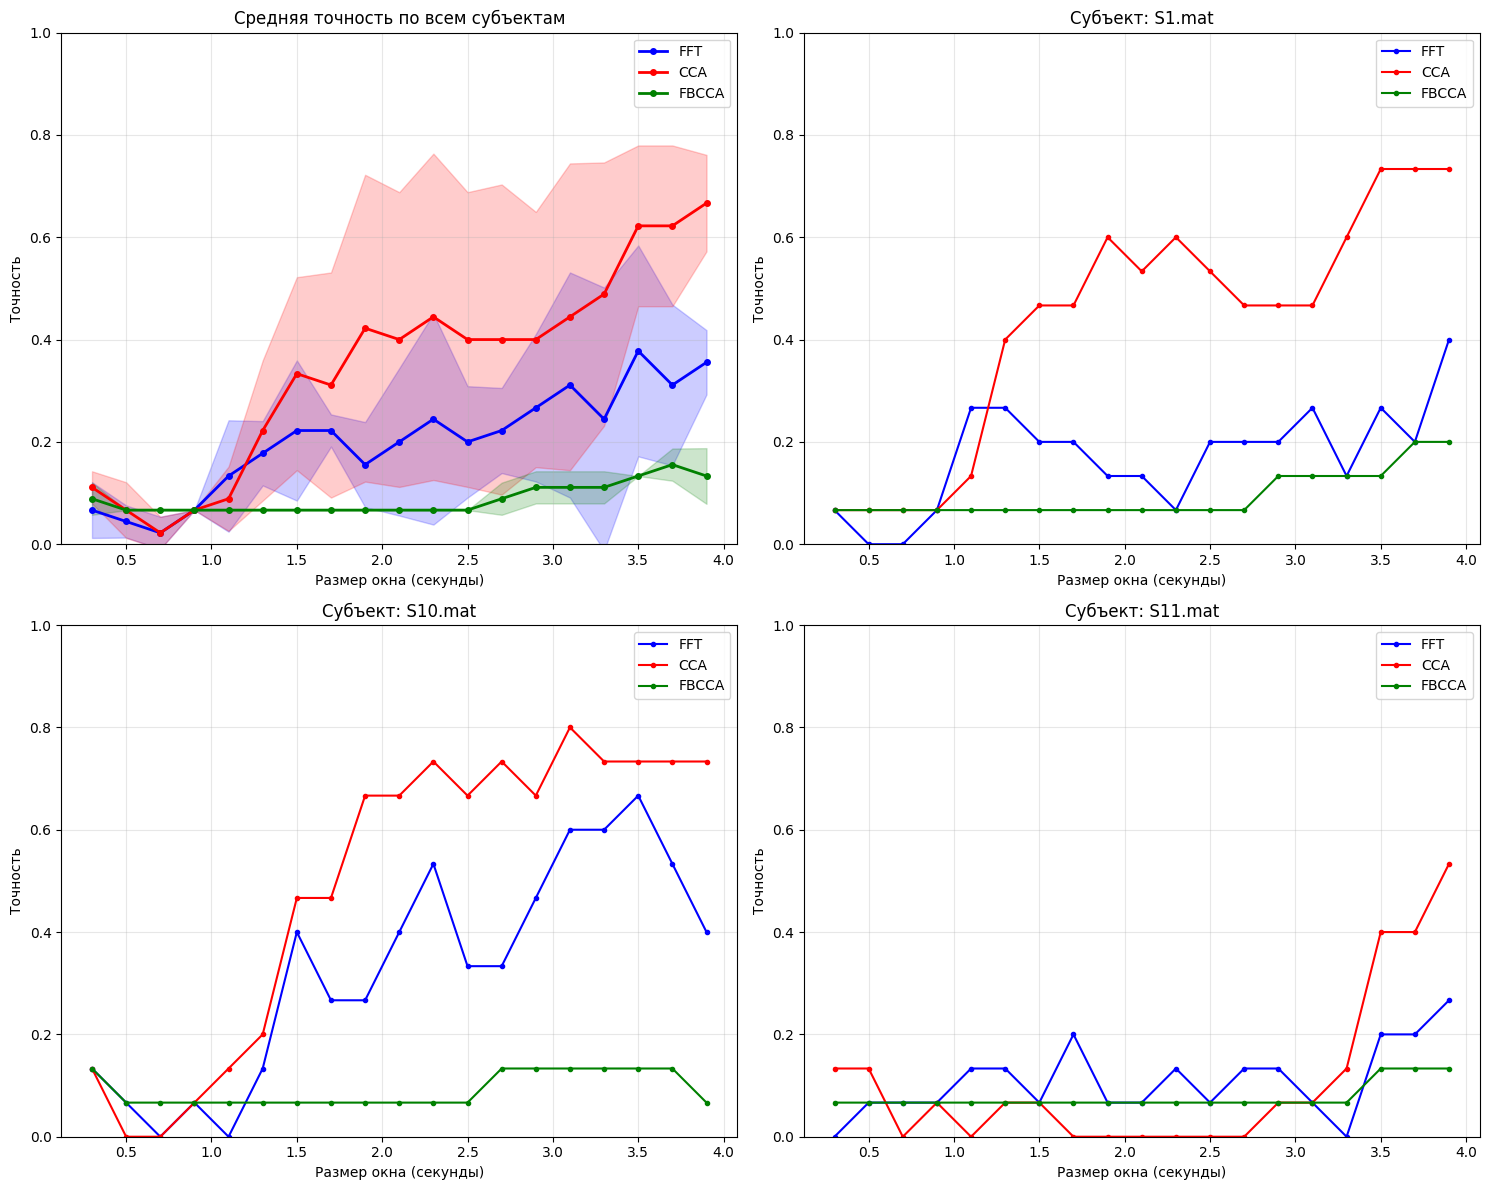

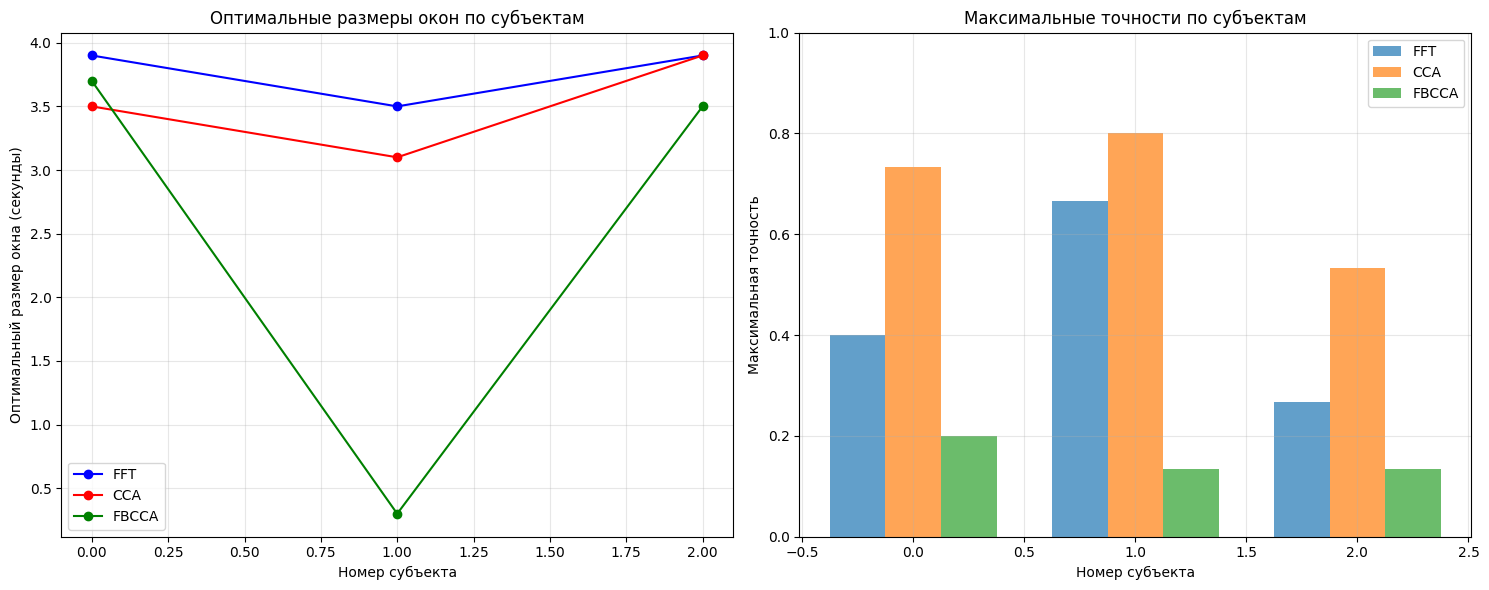


=== СТАТИСТИКА ОПТИМАЛЬНЫХ ОКОН ===
FFT   - Оптимальное окно: 3.77 ± 0.19 с
CCA   - Оптимальное окно: 3.50 ± 0.33 с
FBCCA - Оптимальное окно: 2.50 ± 1.56 с

FFT   - Макс. точность: 0.444 ± 0.166
CCA   - Макс. точность: 0.689 ± 0.113
FBCCA - Макс. точность: 0.156 ± 0.031


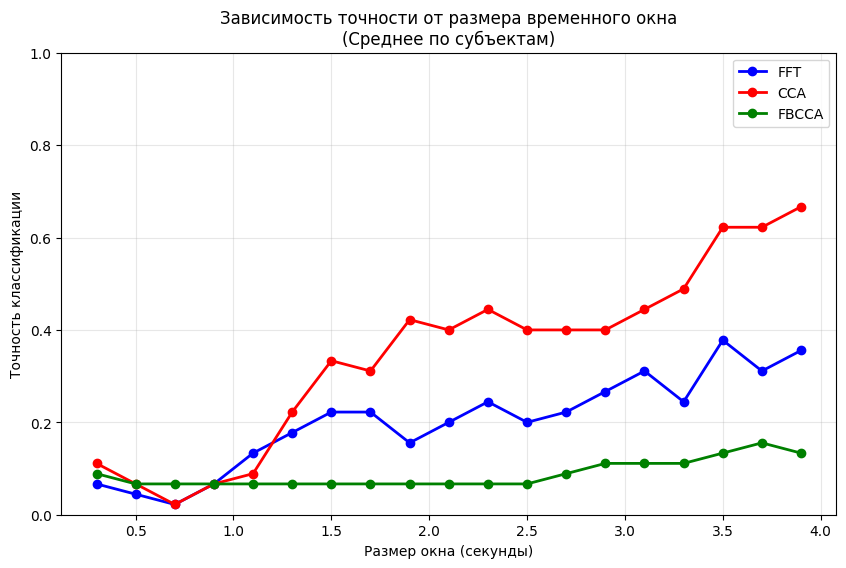

Результаты сохранены в window_size_results_fixed.csv

=== ОТЛАДОЧНАЯ ИНФОРМАЦИЯ ===

Субъект S1.mat:
Количество результатов: 19
Размеры окон: 19
Диапазон: 0.3 - 3.9
Пропущенные размеры: [np.float64(0.1)]

Субъект S10.mat:
Количество результатов: 19
Размеры окон: 19
Диапазон: 0.3 - 3.9
Пропущенные размеры: [np.float64(0.1)]

Субъект S11.mat:
Количество результатов: 19
Размеры окон: 19
Диапазон: 0.3 - 3.9
Пропущенные размеры: [np.float64(0.1)]


In [38]:
# Определяем диапазон размеров окон
window_sizes = np.arange(0.1, 4.1, 0.2)  # от 0.1 до 4 секунд с шагом 0.2
print(f"Будет проанализировано {len(window_sizes)} размеров окон:")
print(f"От {window_sizes[0]} до {window_sizes[-1]} секунд")

# Запускаем анализ для нескольких субъектов
max_subjects = 3  # Уменьшим для тестирования
n_trials = 15     # Количество триалов для анализа

print("Запуск анализа...")
all_results, window_sizes_used = analyze_all_subjects_window_sizes(
    data_path, subject_files, frequencies, window_sizes, max_subjects, n_trials)

# Визуализируем результаты
if all_results:
    results = plot_window_size_results(all_results, window_sizes_used)
    if results is not None:
        mean_fft, mean_cca, mean_fbcca, std_fft, std_cca, std_fbcca, common_window_sizes = results

        # Анализ оптимальных окон
        optimal_results = plot_optimal_windows_analysis(all_results, common_window_sizes)

        # Дополнительная визуализация
        plt.figure(figsize=(10, 6))
        plt.plot(common_window_sizes, mean_fft, 'b-o', label='FFT', linewidth=2)
        plt.plot(common_window_sizes, mean_cca, 'r-o', label='CCA', linewidth=2)
        plt.plot(common_window_sizes, mean_fbcca, 'g-o', label='FBCCA', linewidth=2)

        plt.xlabel('Размер окна (секунды)')
        plt.ylabel('Точность классификации')
        plt.title('Зависимость точности от размера временного окна\n(Среднее по субъектам)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 1)
        plt.show()

        # Сохраняем результаты
        save_window_results_to_csv(all_results, 'window_size_results_fixed.csv')

else:
    print("Нет результатов для визуализации")

# Отладочная информация
if all_results:
    debug_window_analysis(all_results, window_sizes)

In [39]:
def debug_window_analysis(all_results, window_sizes):
    """Отладочная функция для проверки данных"""
    print("\n=== ОТЛАДОЧНАЯ ИНФОРМАЦИЯ ===")

    for subject_file, results in all_results.items():
        print(f"\nСубъект {subject_file}:")
        print(f"Количество результатов: {len(results)}")

        if results:
            window_sizes_subj = [r['window_size'] for r in results]
            print(f"Размеры окон: {len(window_sizes_subj)}")
            print(f"Диапазон: {min(window_sizes_subj):.1f} - {max(window_sizes_subj):.1f}")

            # Проверяем соответствие ожидаемым размерам
            missing_sizes = set(window_sizes) - set(window_sizes_subj)
            if missing_sizes:
                print(f"Пропущенные размеры: {sorted(missing_sizes)}")

# Вызов отладочной функции
if all_results:
    debug_window_analysis(all_results, window_sizes)


=== ОТЛАДОЧНАЯ ИНФОРМАЦИЯ ===

Субъект S1.mat:
Количество результатов: 19
Размеры окон: 19
Диапазон: 0.3 - 3.9
Пропущенные размеры: [np.float64(0.1)]

Субъект S10.mat:
Количество результатов: 19
Размеры окон: 19
Диапазон: 0.3 - 3.9
Пропущенные размеры: [np.float64(0.1)]

Субъект S11.mat:
Количество результатов: 19
Размеры окон: 19
Диапазон: 0.3 - 3.9
Пропущенные размеры: [np.float64(0.1)]


Сохранили результаты

3. Удалить глазодвигательные артефакты с помощью ICA.
3.1 Оценить успешность (сравнение сигнала до и после), и точность работы нейроинтерфейса до и после удаления.
3.2 Расскажите, как выбирали нужные компоненты.
3.3 Как удаление артефактов влияет на точность в данной задаче? Как думаете, почему?

In [40]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import FastICA
import os

class SimpleICA:
    """Упрощенная реализация ICA для удаления артефактов"""

    def __init__(self, sampling_rate=250):
        self.sampling_rate = sampling_rate
        self.ica = None
        self.exclude_components = []

    def fit_ica(self, eeg_data, n_components=8):
        """Обучение ICA модели"""
        print("Обучение ICA модели...")

        # Подготовка данных: [trials, channels, timepoints] -> [channels, timepoints*trials]
        n_trials, n_channels, n_timepoints = eeg_data.shape
        data_reshaped = eeg_data.transpose(1, 0, 2).reshape(n_channels, -1)

        # Применяем ICA
        self.ica = FastICA(n_components=n_components, random_state=42, max_iter=500)
        components = self.ica.fit_transform(data_reshaped.T)  # [samples, components]
        mixing_matrix = self.ica.mixing_  # [channels, components]

        self.components = components.T.reshape(n_components, n_trials, n_timepoints)
        self.mixing_matrix = mixing_matrix

        print(f"ICA обучена с {n_components} компонентами")
        return components, mixing_matrix

    def find_ocular_artifacts(self, eeg_data):
        """Автоматическое обнаружение глазодвигательных артефактов"""
        if self.ica is None:
            raise ValueError("Сначала нужно обучить ICA модель")

        n_components = self.components.shape[0]
        exclude_idx = []

        print("Поиск глазодвигательных артефактов...")

        # Анализ компонентов
        for comp_idx in range(n_components):
            component_data = self.components[comp_idx]  # [trials, timepoints]

            # Критерии для EOG артефактов:
            # 1. Высокая дисперсия
            variance = np.var(component_data)

            # 2. Высокий эксцесс (островершинность) - характерно для артефактов
            kurtosis_val = stats.kurtosis(component_data.flatten())

            # 3. Низкочастотные характеристики (EOG обычно 0.1-5 Hz)
            component_flat = component_data.flatten()
            psd = np.abs(np.fft.fft(component_flat))**2
            freqs = np.fft.fftfreq(len(component_flat), 1/self.sampling_rate)
            low_freq_mask = (freqs > 0.1) & (freqs < 5)
            low_freq_power = np.mean(psd[low_freq_mask]) if np.any(low_freq_mask) else 0

            # 4. Амплитуда (артефакты обычно высокоамплитудные)
            amplitude = np.max(np.abs(component_data))

            # Нормализуем критерии
            max_variance = max([np.var(self.components[i]) for i in range(n_components)])
            max_kurtosis = max([abs(stats.kurtosis(self.components[i].flatten())) for i in range(n_components)])
            max_amplitude = max([np.max(np.abs(self.components[i])) for i in range(n_components)])

            norm_variance = variance / max_variance if max_variance > 0 else 0
            norm_kurtosis = abs(kurtosis_val) / max_kurtosis if max_kurtosis > 0 else 0
            norm_amplitude = amplitude / max_amplitude if max_amplitude > 0 else 0

            # Комбинированная оценка (больший вес для дисперсии и амплитуды)
            score = 0.4 * norm_variance + 0.3 * norm_kurtosis + 0.3 * norm_amplitude

            # Порог для идентификации артефактов
            if score > 0.6:  # Эмпирический порог
                exclude_idx.append(comp_idx)
                print(f"Компонент {comp_idx}: score={score:.3f} (var={norm_variance:.3f}, kurt={norm_kurtosis:.3f}, amp={norm_amplitude:.3f}) - АРТЕФАКТ")
            else:
                print(f"Компонент {comp_idx}: score={score:.3f} - чистый")

        self.exclude_components = exclude_idx
        print(f"Всего найдено артефактных компонентов: {len(exclude_idx)}")
        return exclude_idx

    def remove_artifacts(self, eeg_data):
        """Удаление артефактов из данных"""
        if self.ica is None:
            raise ValueError("Сначала нужно обучить ICA модель")

        n_trials, n_channels, n_timepoints = eeg_data.shape

        # Реконструкция данных без исключенных компонентов
        data_reshaped = eeg_data.transpose(1, 0, 2).reshape(n_channels, -1)

        # Преобразование в пространство компонентов
        components = self.ica.transform(data_reshaped.T)  # [samples, components]

        # Обнуляем исключенные компоненты
        components_clean = components.copy()
        for comp_idx in self.exclude_components:
            components_clean[:, comp_idx] = 0

        # Обратное преобразование
        data_clean = self.ica.inverse_transform(components_clean).T
        data_clean = data_clean.reshape(n_channels, n_trials, n_timepoints).transpose(1, 0, 2)

        print(f"Удалены компоненты: {self.exclude_components}")
        return data_clean

    def visualize_components(self, eeg_data, n_components_to_show=8):
        """Визуализация ICA компонентов"""
        if self.ica is None:
            raise ValueError("Сначала нужно обучить ICA модель")

        n_components = min(n_components_to_show, self.components.shape[0])

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.flatten()

        for i in range(min(4, n_components)):
            component_data = self.components[i]

            # Временной ряд первого триала
            time_points = np.arange(len(component_data[0])) / self.sampling_rate
            axes[i].plot(time_points, component_data[0], 'b-', linewidth=1)

            artifact_status = "АРТЕФАКТ" if i in self.exclude_components else "чистый"
            axes[i].set_title(f'Компонент {i} - {artifact_status}')
            axes[i].set_xlabel('Время (с)')
            axes[i].set_ylabel('Амплитуда')
            axes[i].grid(True, alpha=0.3)

            if i in self.exclude_components:
                axes[i].set_facecolor('#FFE4E1')  # Светло-красный фон для артефактов

        plt.tight_layout()
        plt.suptitle('Визуализация ICA компонентов', y=1.02)
        plt.show()

In [41]:
class ICAComparison:
    """Сравнение точности до и после ICA очистки"""

    def __init__(self, sampling_rate=250):
        self.sampling_rate = sampling_rate
        self.ica_processor = SimpleICA(sampling_rate)

    def compare_signals(self, original_data, clean_data, channel_names, trial_idx=0):
        """Сравнение сигналов до и после очистки"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Выбираем каналы для отображения
        channels_to_plot = min(4, original_data.shape[1])

        for i in range(channels_to_plot):
            row = i // 2
            col = i % 2

            time_points = np.arange(original_data.shape[2]) / self.sampling_rate

            axes[row, col].plot(time_points, original_data[trial_idx, i], 'b-',
                              alpha=0.7, label='До очистки', linewidth=1)
            axes[row, col].plot(time_points, clean_data[trial_idx, i], 'r-',
                              alpha=0.7, label='После очистки', linewidth=1)
            axes[row, col].set_title(f'Канал {i}')
            axes[row, col].set_xlabel('Время (с)')
            axes[row, col].set_ylabel('Амплитуда')
            axes[row, col].legend()
            axes[row, col].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.suptitle('Сравнение EEG сигналов до и после ICA очистки', y=1.02)
        plt.show()

        # Количественная оценка
        self.quantify_improvement(original_data, clean_data)

    def quantify_improvement(self, original_data, clean_data):
        """Количественная оценка улучшений"""
        # Статистика по всем каналам и триалам
        orig_std = np.std(original_data, axis=(0, 2))  # STD по каналам
        clean_std = np.std(clean_data, axis=(0, 2))

        improvement_std = (orig_std - clean_std) / orig_std * 100

        print("\n=== КОЛИЧЕСТВЕННАЯ ОЦЕНКА УЛУЧШЕНИЙ ===")
        print(f"Среднее уменьшение STD: {np.mean(improvement_std):.1f}%")
        print(f"Максимальное улучшение по каналу: {np.max(improvement_std):.1f}%")
        print(f"Минимальное улучшение по каналу: {np.min(improvement_std):.1f}%")

        # Анализ SNR
        orig_snr = self.calculate_snr(original_data)
        clean_snr = self.calculate_snr(clean_data)
        snr_improvement = (clean_snr - orig_snr) / orig_snr * 100

        print(f"Улучшение SNR: {snr_improvement:.1f}%")

        return np.mean(improvement_std)

    def calculate_snr(self, data):
        """Оценка SNR в данных"""
        # Простая оценка SNR через отношение мощности сигнала к шуму
        signal_power = np.mean(data**2)
        noise_estimate = data - np.mean(data, axis=2, keepdims=True)
        noise_power = np.mean(noise_estimate**2)

        if noise_power > 0:
            return 10 * np.log10(signal_power / noise_power)
        else:
            return 0

In [42]:
def analyze_ica_impact(data_path, subject_files, frequencies, channel_names, n_subjects=3, n_trials=20):
    """Анализ влияния ICA очистки на точность SSVEP-BCI"""

    target_indices = [0,1,2,3,4,5,6,7,16,17,18,19,20,21,22,23]
    target_frequencies = frequencies[target_indices]

    results = {}

    for i, subject_file in enumerate(subject_files[:n_subjects]):
        print(f"\n{'='*60}")
        print(f"АНАЛИЗ СУБЪЕКТА {i+1}/{n_subjects}: {subject_file}")
        print(f"{'='*60}")

        try:
            # Загрузка данных
            full_path = os.path.join(data_path, subject_file)
            data_dict = sio.loadmat(full_path)
            eeg_data = data_dict['data']

            # Предобработка данных
            processed_data, _, _ = preprocess_data(
                eeg_data, target_indices, data_length=1.0)

            # Используем только часть триалов для ускорения
            analysis_data = processed_data[:n_trials]

            # Анализ БЕЗ ICA
            print("\n1. АНАЛИЗ БЕЗ ICA ОЧИСТКИ:")
            accuracy_no_ica = evaluate_accuracy_methods(analysis_data, target_frequencies)

            # Анализ С ICA
            print("\n2. АНАЛИЗ С ICA ОЧИСТКОЙ:")
            ica_comparison = ICAComparison(sampling_rate=250)

            # Применяем ICA
            ica_comparison.ica_processor.fit_ica(analysis_data, n_components=8)
            ica_comparison.ica_processor.find_ocular_artifacts(analysis_data)
            clean_data = ica_comparison.ica_processor.remove_artifacts(analysis_data)

            # Визуализация компонентов
            ica_comparison.ica_processor.visualize_components(analysis_data)

            # Сравнение сигналов
            ica_comparison.compare_signals(analysis_data, clean_data, channel_names)

            # Оценка точности на очищенных данных
            accuracy_with_ica = evaluate_accuracy_methods(clean_data, target_frequencies)

            results[subject_file] = {
                'no_ica': accuracy_no_ica,
                'with_ica': accuracy_with_ica,
                'improvement': {
                    'overall': accuracy_with_ica['overall'] - accuracy_no_ica['overall'],
                    'fft': accuracy_with_ica['fft'] - accuracy_no_ica['fft'],
                    'cca': accuracy_with_ica['cca'] - accuracy_no_ica['cca'],
                    'fbcca': accuracy_with_ica['fbcca'] - accuracy_no_ica['fbcca']
                }
            }

            print(f"\nРЕЗУЛЬТАТЫ ДЛЯ {subject_file}:")
            print(f"БЕЗ ICA: FFT={accuracy_no_ica['fft']:.3f}, CCA={accuracy_no_ica['cca']:.3f}, FBCCA={accuracy_no_ica['fbcca']:.3f}")
            print(f"С ICA:  FFT={accuracy_with_ica['fft']:.3f}, CCA={accuracy_with_ica['cca']:.3f}, FBCCA={accuracy_with_ica['fbcca']:.3f}")
            print(f"УЛУЧШЕНИЕ: FFT={results[subject_file]['improvement']['fft']:+.3f}, "
                  f"CCA={results[subject_file]['improvement']['cca']:+.3f}, "
                  f"FBCCA={results[subject_file]['improvement']['fbcca']:+.3f}")

        except Exception as e:
            print(f"Ошибка при обработке {subject_file}: {e}")
            continue

    return results

def evaluate_accuracy_methods(processed_data, target_frequencies):
    """Оценка точности всех методов"""
    fft_detector = FFTDetector(sampling_rate=250)
    cca_detector = CCADetector(sampling_rate=250, num_harmonics=5)
    fbcca_detector = FBCCADetector(sampling_rate=250, num_harmonics=5, num_sub_bands=5)

    n_trials = processed_data.shape[0]

    fft_predictions = []
    cca_predictions = []
    fbcca_predictions = []
    true_labels = []

    for trial_idx in range(n_trials):
        true_label = trial_idx % len(target_frequencies)
        true_labels.append(true_label)

        trial_data = processed_data[trial_idx]

        fft_pred, _ = fft_detector.classify_trial(trial_data, target_frequencies)
        cca_pred, _ = cca_detector.classify_trial(trial_data, target_frequencies)
        fbcca_pred, _ = fbcca_detector.classify_trial(trial_data, target_frequencies)

        fft_predictions.append(fft_pred)
        cca_predictions.append(cca_pred)
        fbcca_predictions.append(fbcca_pred)

    true_labels = np.array(true_labels)
    fft_accuracy = np.mean(np.array(fft_predictions) == true_labels)
    cca_accuracy = np.mean(np.array(cca_predictions) == true_labels)
    fbcca_accuracy = np.mean(np.array(fbcca_predictions) == true_labels)

    return {
        'overall': (fft_accuracy + cca_accuracy + fbcca_accuracy) / 3,
        'fft': fft_accuracy,
        'cca': cca_accuracy,
        'fbcca': fbcca_accuracy
    }

In [43]:
def plot_ica_impact_results(results):
    """Визуализация влияния ICA на точность"""
    subjects = list(results.keys())

    # Подготовка данных
    acc_no_ica = [results[s]['no_ica']['overall'] for s in subjects]
    acc_with_ica = [results[s]['with_ica']['overall'] for s in subjects]
    improvements = [results[s]['improvement']['overall'] for s in subjects]

    # Методы
    methods = ['FFT', 'CCA', 'FBCCA']
    acc_no_ica_methods = np.array([[results[s]['no_ica'][method.lower()] for s in subjects] for method in methods])
    acc_with_ica_methods = np.array([[results[s]['with_ica'][method.lower()] for s in subjects] for method in methods])

    # Графики
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Общая точность
    x_pos = np.arange(len(subjects))
    width = 0.35

    ax1.bar(x_pos - width/2, acc_no_ica, width, label='Без ICA', alpha=0.7, color='blue')
    ax1.bar(x_pos + width/2, acc_with_ica, width, label='С ICA', alpha=0.7, color='red')
    ax1.set_xlabel('Субъекты')
    ax1.set_ylabel('Точность')
    ax1.set_title('Общая точность до и после ICA')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([s.replace('.mat', '') for s in subjects])
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Улучшения
    colors = ['green' if imp >= 0 else 'red' for imp in improvements]
    bars = ax2.bar(x_pos, improvements, color=colors, alpha=0.7)
    ax2.set_xlabel('Субъекты')
    ax2.set_ylabel('Улучшение точности')
    ax2.set_title('Улучшение точности после ICA')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([s.replace('.mat', '') for s in subjects])
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax2.grid(True, alpha=0.3)

    # Добавляем значения
    for i, bar in enumerate(bars):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.01 if bar.get_height() >= 0 else -0.02),
                f'{improvements[i]:.3f}', ha='center', va='bottom' if bar.get_height() >= 0 else 'top',
                fontsize=8)

    # 3. Точность по методам (без ICA)
    for i, method in enumerate(methods):
        ax3.bar(x_pos + (i-1)*width, acc_no_ica_methods[i], width, label=method, alpha=0.7)
    ax3.set_xlabel('Субъекты')
    ax3.set_ylabel('Точность')
    ax3.set_title('Точность по методам (БЕЗ ICA)')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels([s.replace('.mat', '') for s in subjects])
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Точность по методам (с ICA)
    for i, method in enumerate(methods):
        ax4.bar(x_pos + (i-1)*width, acc_with_ica_methods[i], width, label=method, alpha=0.7)
    ax4.set_xlabel('Субъекты')
    ax4.set_ylabel('Точность')
    ax4.set_title('Точность по методам (С ICA)')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels([s.replace('.mat', '') for s in subjects])
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Статистический анализ
    print("\n" + "="*60)
    print("СТАТИСТИЧЕСКИЙ АНАЛИЗ ВЛИЯНИЯ ICA")
    print("="*60)

    # T-тесты для каждого метода
    from scipy import stats

    print("\nСтатистическая значимость улучшений:")
    for i, method in enumerate(methods):
        t_stat, p_value = stats.ttest_rel(acc_with_ica_methods[i], acc_no_ica_methods[i])
        mean_improvement = np.mean(acc_with_ica_methods[i] - acc_no_ica_methods[i])

        significance = "✅ СТАТИСТИЧЕСКИ ЗНАЧИМО" if p_value < 0.05 else "❌ не значимо"
        print(f"{method}: улучшение = {mean_improvement:+.3f}, p-value = {p_value:.4f} {significance}")

    # Общая статистика
    print(f"\nОБЩАЯ СТАТИСТИКА:")
    print(f"Средняя точность БЕЗ ICA: {np.mean(acc_no_ica):.3f} ± {np.std(acc_no_ica):.3f}")
    print(f"Средняя точность С ICA: {np.mean(acc_with_ica):.3f} ± {np.std(acc_with_ica):.3f}")
    print(f"Среднее улучшение: {np.mean(improvements):.3f} ± {np.std(improvements):.3f}")

    positive_improvements = sum(1 for imp in improvements if imp > 0)
    print(f"Субъектов с улучшением: {positive_improvements}/{len(subjects)} ({positive_improvements/len(subjects)*100:.1f}%)")

    return {
        'subjects': subjects,
        'acc_no_ica': acc_no_ica,
        'acc_with_ica': acc_with_ica,
        'improvements': improvements,
        't_stats': [stats.ttest_rel(acc_with_ica_methods[i], acc_no_ica_methods[i])[0] for i in range(len(methods))],
        'p_values': [stats.ttest_rel(acc_with_ica_methods[i], acc_no_ica_methods[i])[1] for i in range(len(methods))]
    }

=== АНАЛИЗ ВЛИЯНИЯ ICA НА ТОЧНОСТЬ SSVEP-BCI ===

АНАЛИЗ СУБЪЕКТА 1/3: S1.mat
Данные после предобработки: (96, 8, 250)
Временное окно: 35-285 отсчетов (0.14-1.1400000000000001 секунд)

1. АНАЛИЗ БЕЗ ICA ОЧИСТКИ:

2. АНАЛИЗ С ICA ОЧИСТКОЙ:
Обучение ICA модели...
ICA обучена с 8 компонентами
Поиск глазодвигательных артефактов...
Компонент 0: score=0.700 (var=1.000, kurt=0.133, amp=0.866) - АРТЕФАКТ
Компонент 1: score=0.763 (var=1.000, kurt=0.359, amp=0.853) - АРТЕФАКТ
Компонент 2: score=0.674 (var=1.000, kurt=0.223, amp=0.689) - АРТЕФАКТ
Компонент 3: score=0.882 (var=1.000, kurt=0.607, amp=1.000) - АРТЕФАКТ
Компонент 4: score=0.675 (var=1.000, kurt=0.089, amp=0.826) - АРТЕФАКТ
Компонент 5: score=0.987 (var=1.000, kurt=1.000, amp=0.957) - АРТЕФАКТ
Компонент 6: score=0.925 (var=1.000, kurt=0.953, amp=0.797) - АРТЕФАКТ
Компонент 7: score=0.656 (var=1.000, kurt=0.031, amp=0.824) - АРТЕФАКТ
Всего найдено артефактных компонентов: 8
Удалены компоненты: [0, 1, 2, 3, 4, 5, 6, 7]


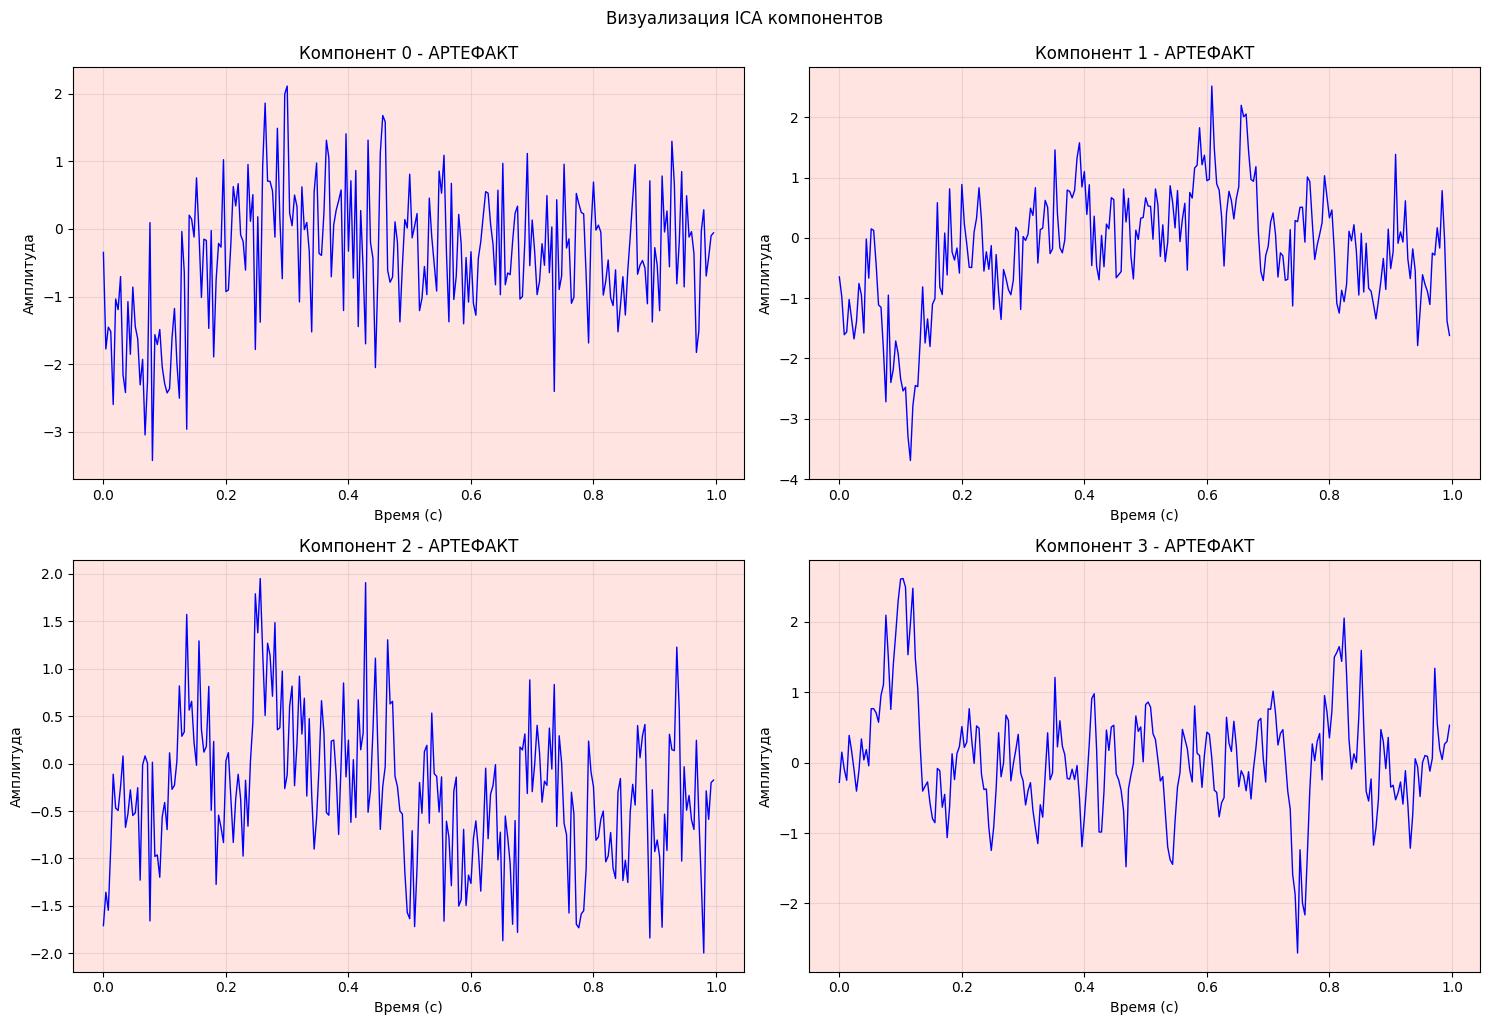

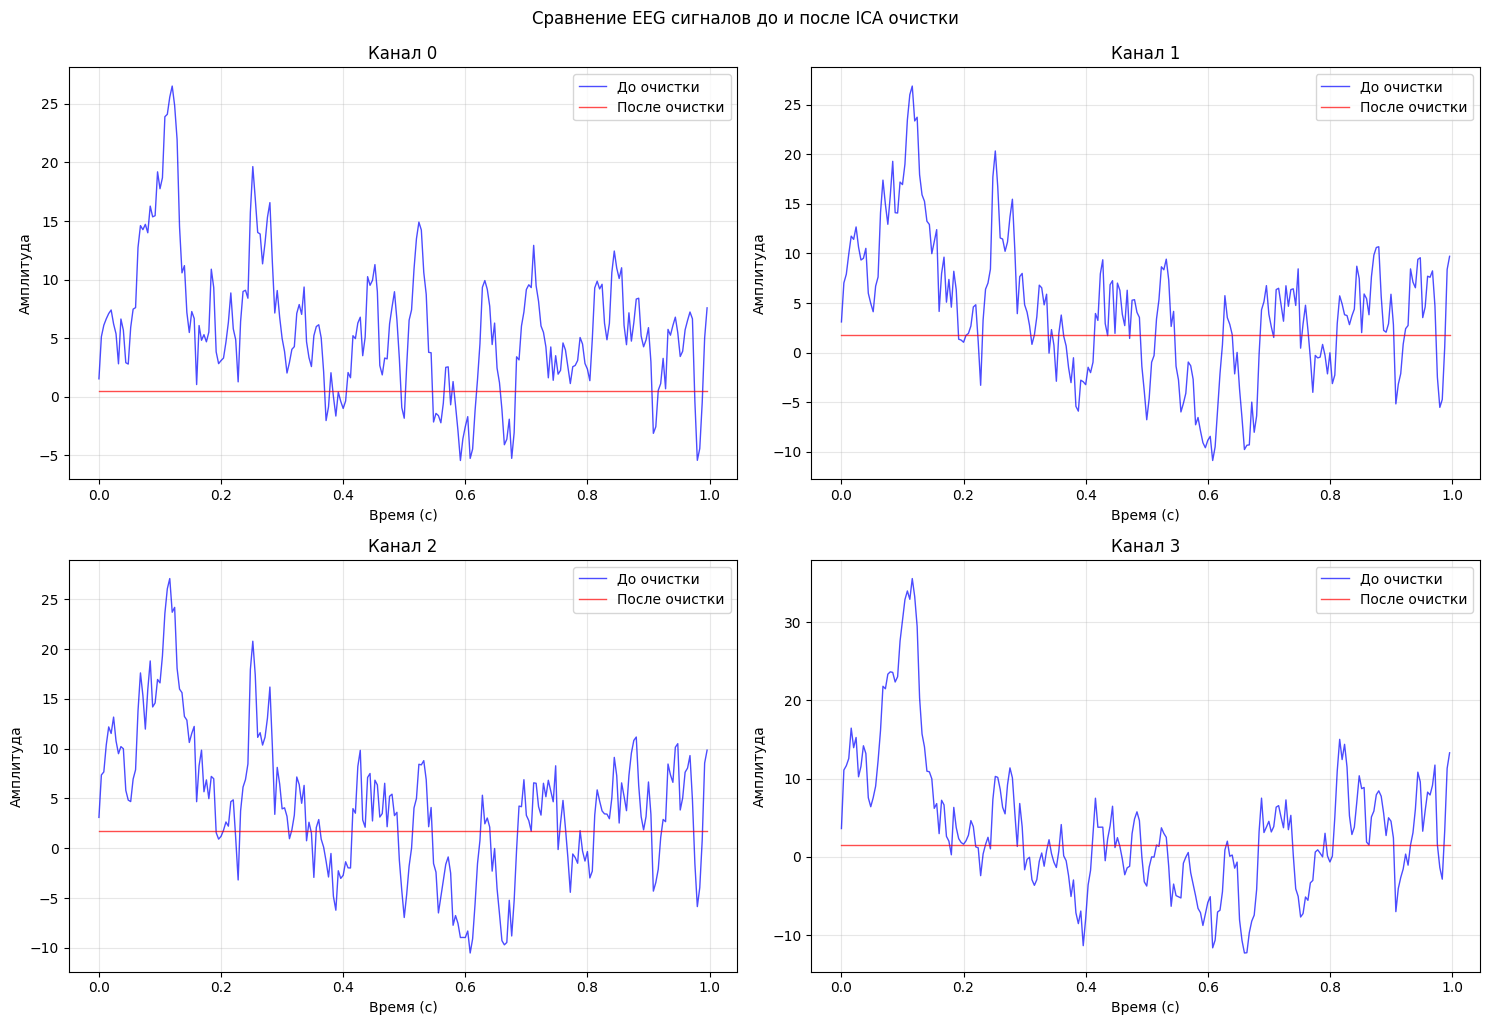


=== КОЛИЧЕСТВЕННАЯ ОЦЕНКА УЛУЧШЕНИЙ ===
Среднее уменьшение STD: 100.0%
Максимальное улучшение по каналу: 100.0%
Минимальное улучшение по каналу: 100.0%
Улучшение SNR: 23740.5%

РЕЗУЛЬТАТЫ ДЛЯ S1.mat:
БЕЗ ICA: FFT=0.150, CCA=0.050, FBCCA=0.100
С ICA:  FFT=0.100, CCA=0.050, FBCCA=0.100
УЛУЧШЕНИЕ: FFT=-0.050, CCA=+0.000, FBCCA=+0.000

АНАЛИЗ СУБЪЕКТА 2/3: S10.mat
Данные после предобработки: (96, 8, 250)
Временное окно: 35-285 отсчетов (0.14-1.1400000000000001 секунд)

1. АНАЛИЗ БЕЗ ICA ОЧИСТКИ:

2. АНАЛИЗ С ICA ОЧИСТКОЙ:
Обучение ICA модели...
ICA обучена с 8 компонентами
Поиск глазодвигательных артефактов...
Компонент 0: score=0.465 - чистый
Компонент 1: score=1.000 (var=1.000, kurt=1.000, amp=1.000) - АРТЕФАКТ
Компонент 2: score=0.495 - чистый
Компонент 3: score=0.537 - чистый
Компонент 4: score=0.536 - чистый
Компонент 5: score=0.484 - чистый
Компонент 6: score=0.508 - чистый
Компонент 7: score=0.478 - чистый
Всего найдено артефактных компонентов: 1
Удалены компоненты: [1]


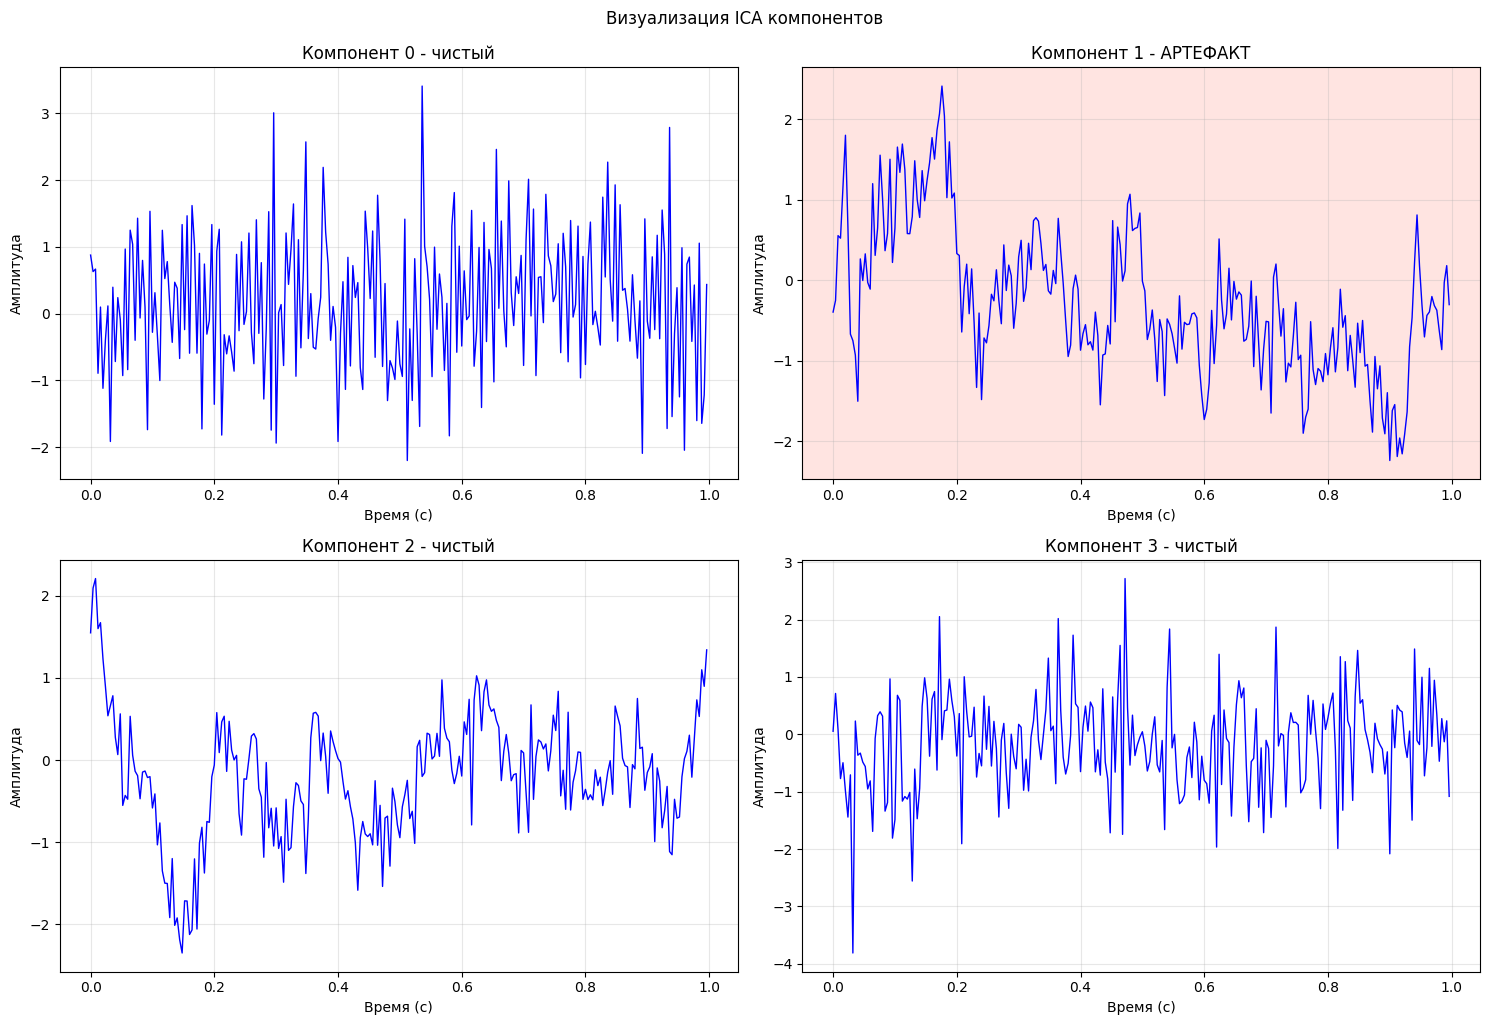

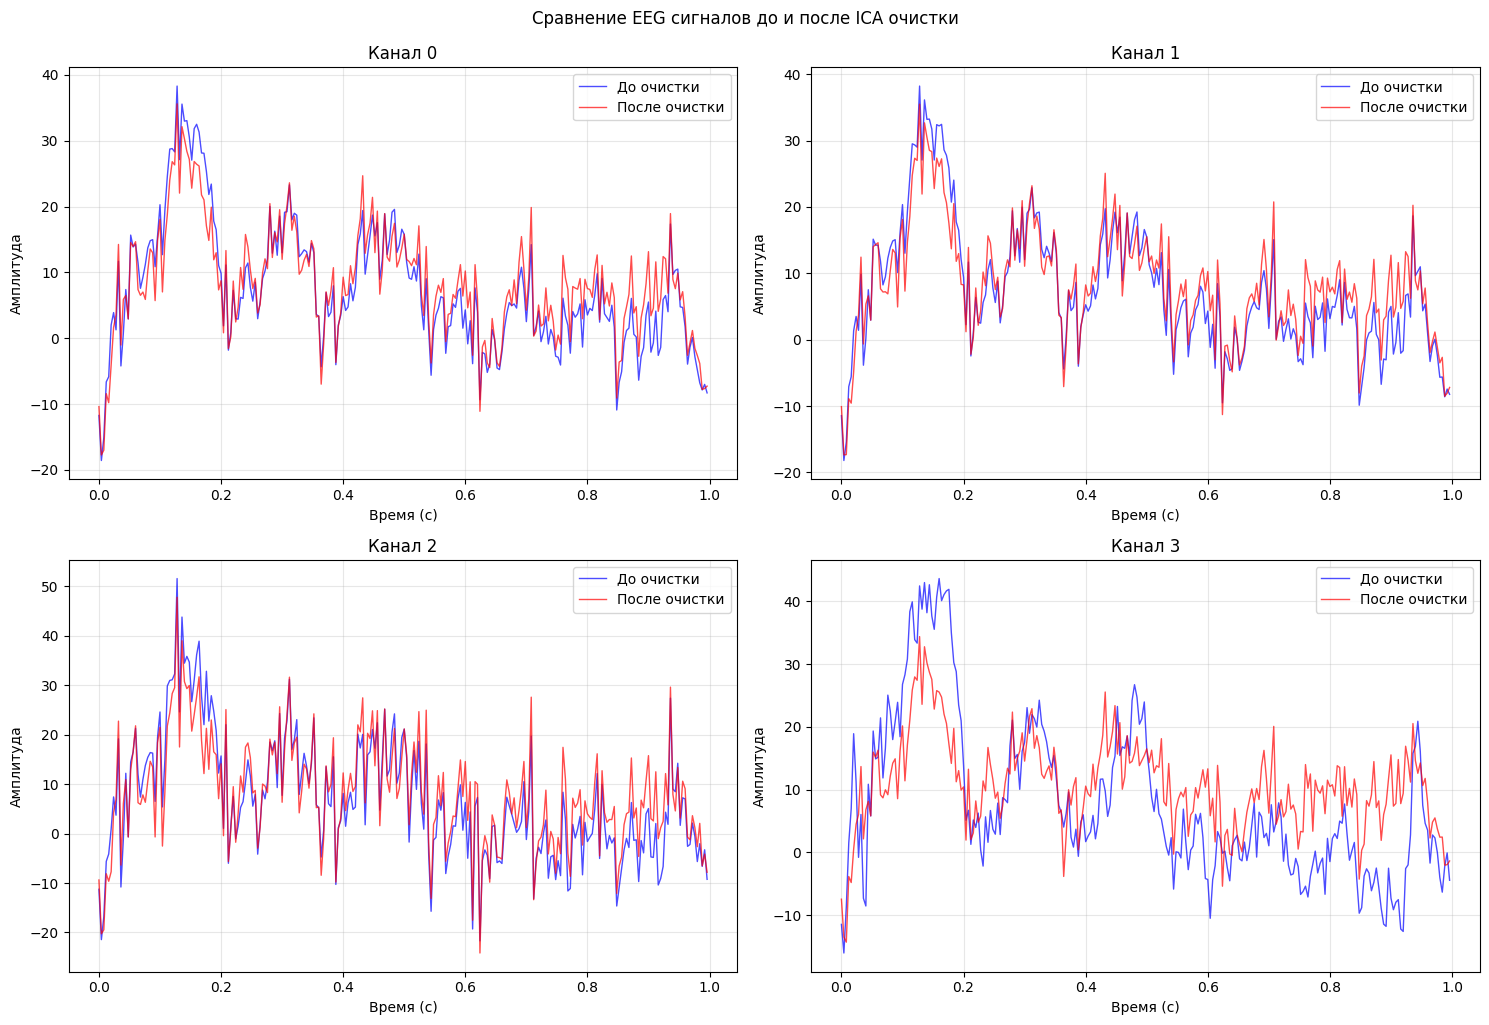


=== КОЛИЧЕСТВЕННАЯ ОЦЕНКА УЛУЧШЕНИЙ ===
Среднее уменьшение STD: 13.5%
Максимальное улучшение по каналу: 29.8%
Минимальное улучшение по каналу: 4.2%
Улучшение SNR: 29.3%

РЕЗУЛЬТАТЫ ДЛЯ S10.mat:
БЕЗ ICA: FFT=0.100, CCA=0.100, FBCCA=0.100
С ICA:  FFT=0.100, CCA=0.200, FBCCA=0.100
УЛУЧШЕНИЕ: FFT=+0.000, CCA=+0.100, FBCCA=+0.000

АНАЛИЗ СУБЪЕКТА 3/3: S11.mat
Данные после предобработки: (96, 8, 250)
Временное окно: 35-285 отсчетов (0.14-1.1400000000000001 секунд)

1. АНАЛИЗ БЕЗ ICA ОЧИСТКИ:

2. АНАЛИЗ С ICA ОЧИСТКОЙ:
Обучение ICA модели...
ICA обучена с 8 компонентами
Поиск глазодвигательных артефактов...
Компонент 0: score=0.568 - чистый
Компонент 1: score=1.000 (var=1.000, kurt=1.000, amp=1.000) - АРТЕФАКТ
Компонент 2: score=0.779 (var=1.000, kurt=0.578, amp=0.686) - АРТЕФАКТ
Компонент 3: score=0.619 (var=1.000, kurt=0.070, amp=0.660) - АРТЕФАКТ
Компонент 4: score=0.717 (var=1.000, kurt=0.404, amp=0.652) - АРТЕФАКТ
Компонент 5: score=0.830 (var=1.000, kurt=0.720, amp=0.715) - АРТЕФАКТ
Ко

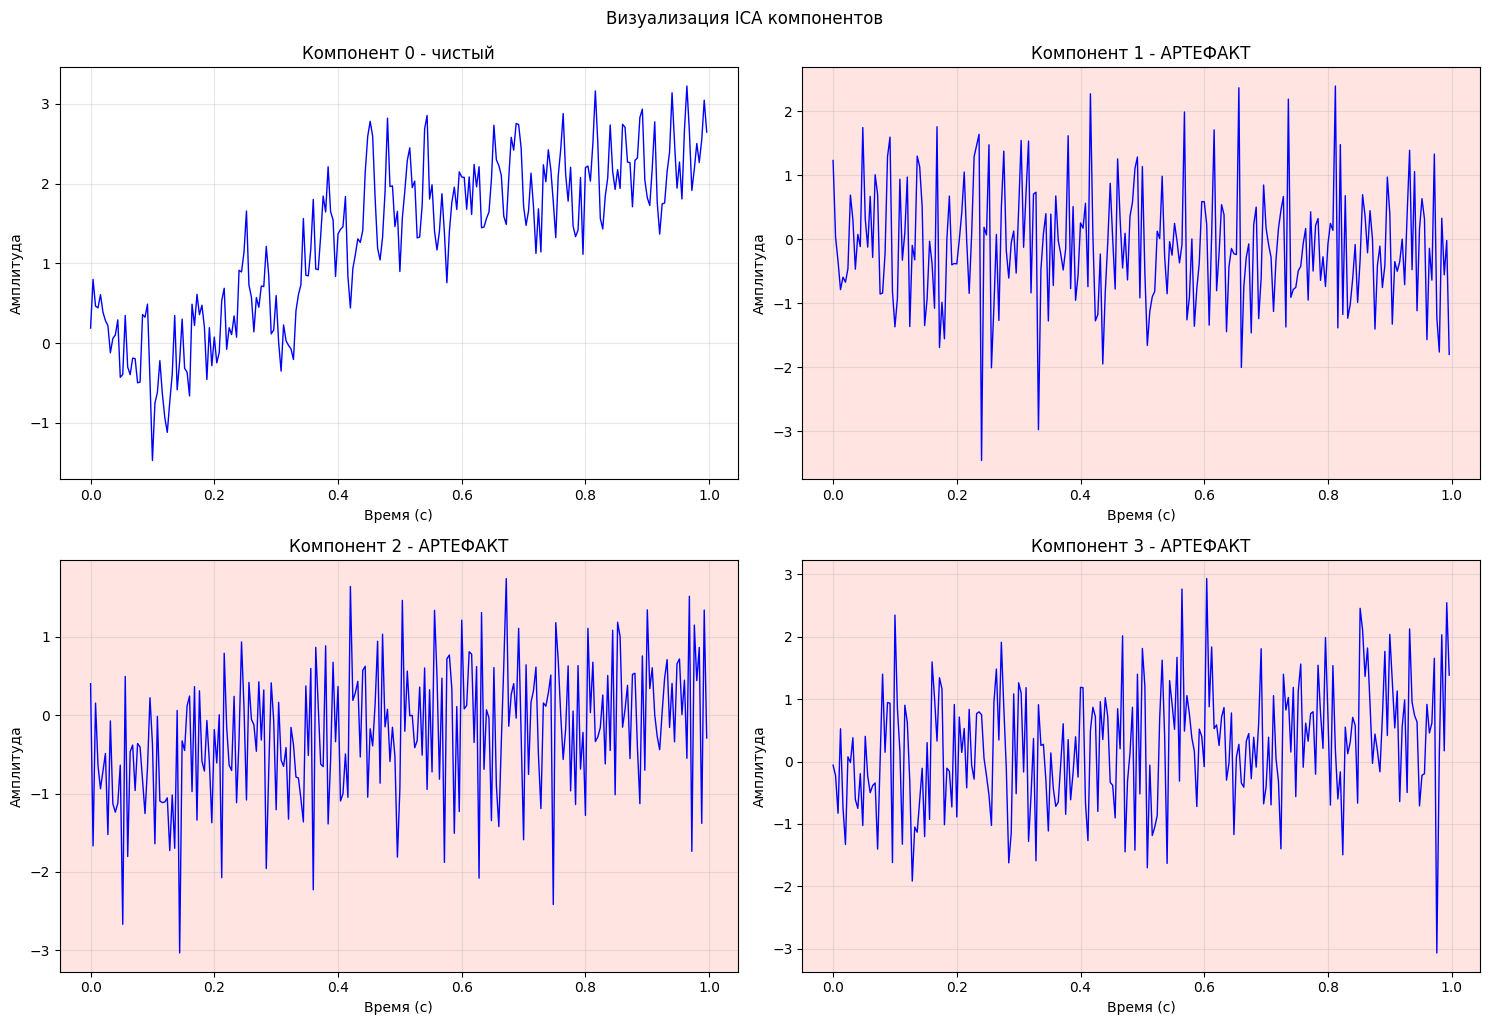

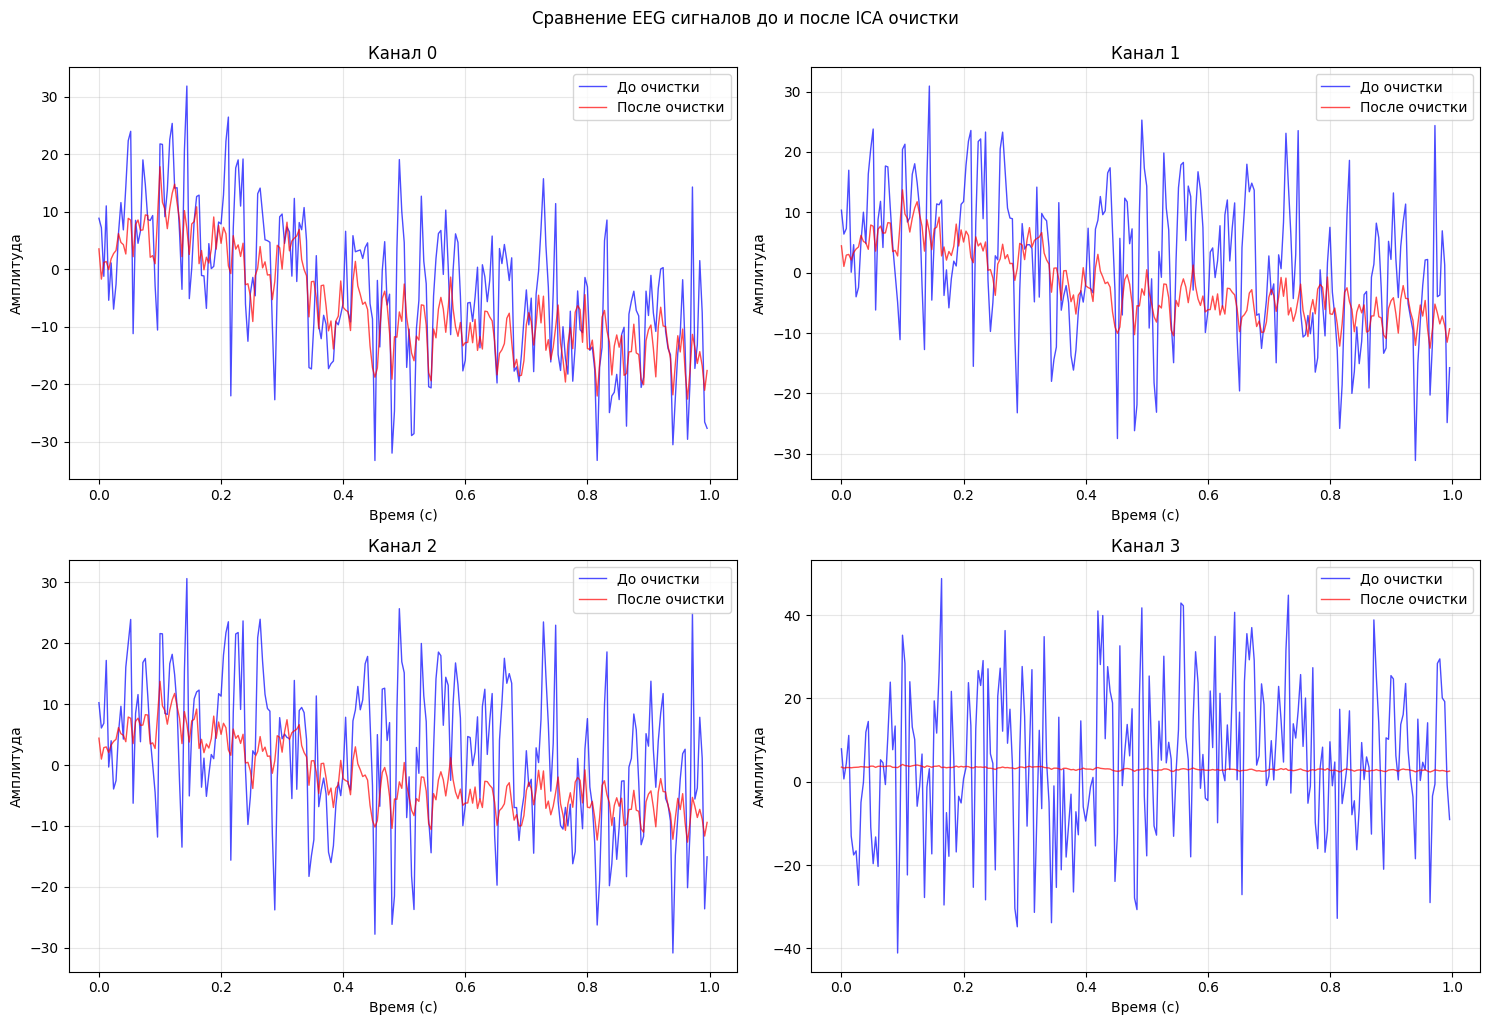


=== КОЛИЧЕСТВЕННАЯ ОЦЕНКА УЛУЧШЕНИЙ ===
Среднее уменьшение STD: 77.5%
Максимальное улучшение по каналу: 97.8%
Минимальное улучшение по каналу: 38.4%
Улучшение SNR: 1407.5%

РЕЗУЛЬТАТЫ ДЛЯ S11.mat:
БЕЗ ICA: FFT=0.050, CCA=0.100, FBCCA=0.100
С ICA:  FFT=0.150, CCA=0.100, FBCCA=0.000
УЛУЧШЕНИЕ: FFT=+0.100, CCA=+0.000, FBCCA=-0.100


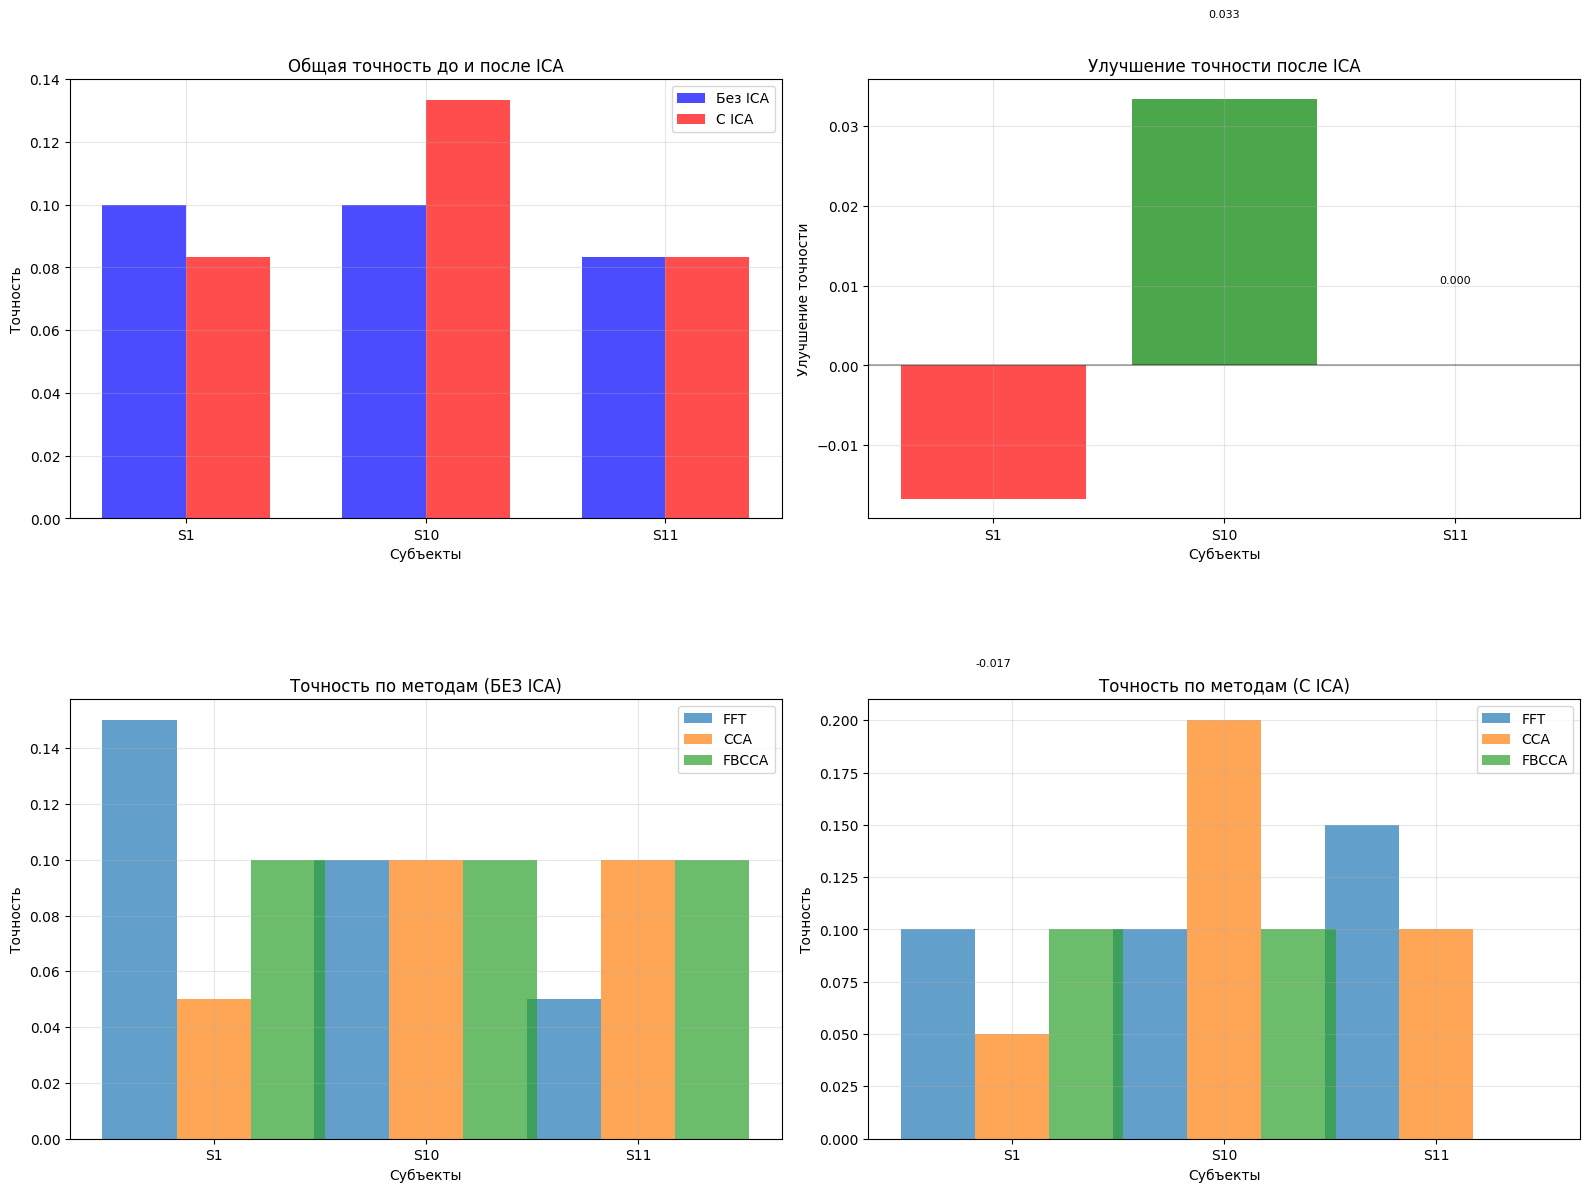


СТАТИСТИЧЕСКИЙ АНАЛИЗ ВЛИЯНИЯ ICA

Статистическая значимость улучшений:
FFT: улучшение = +0.017, p-value = 0.7418 ❌ не значимо
CCA: улучшение = +0.033, p-value = 0.4226 ❌ не значимо
FBCCA: улучшение = -0.033, p-value = 0.4226 ❌ не значимо

ОБЩАЯ СТАТИСТИКА:
Средняя точность БЕЗ ICA: 0.094 ± 0.008
Средняя точность С ICA: 0.100 ± 0.024
Среднее улучшение: 0.006 ± 0.021
Субъектов с улучшением: 1/3 (33.3%)
Результаты сохранены в ica_impact_results.csv


In [44]:
# Запускаем анализ влияния ICA
print("=== АНАЛИЗ ВЛИЯНИЯ ICA НА ТОЧНОСТЬ SSVEP-BCI ===")
ica_results = analyze_ica_impact(data_path, subject_files, frequencies, channel_names,
                               n_subjects=3, n_trials=20)

if ica_results:
    stats_results = plot_ica_impact_results(ica_results)

    # Сохраняем результаты
    import pandas as pd
    ica_df = pd.DataFrame([
        {
            'subject': subject,
            'fft_no_ica': results['no_ica']['fft'],
            'cca_no_ica': results['no_ica']['cca'],
            'fbcca_no_ica': results['no_ica']['fbcca'],
            'fft_with_ica': results['with_ica']['fft'],
            'cca_with_ica': results['with_ica']['cca'],
            'fbcca_with_ica': results['with_ica']['fbcca'],
            'improvement_fft': results['improvement']['fft'],
            'improvement_cca': results['improvement']['cca'],
            'improvement_fbcca': results['improvement']['fbcca']
        }
        for subject, results in ica_results.items()
    ])
    ica_df.to_csv('ica_impact_results.csv', index=False)
    print("Результаты сохранены в ica_impact_results.csv")

else:
    print("Не удалось получить результаты ICA анализа")

Визуализация 1: В результате для одного человека картинка может выглядеть примерно так (по X - размер окна, по которому принимается решение, по У - точность)


In [45]:
def plot_single_subject_window_analysis(subject_file, data_path, frequencies, window_sizes=None, n_trials=20):
    """
    Визуализация зависимости точности от размера окна для одного субъекта
    """
    if window_sizes is None:
        window_sizes = np.arange(0.1, 4.1, 0.2)  # от 0.1 до 4 секунд с шагом 0.2

    print(f"=== АНАЛИЗ РАЗМЕРОВ ОКОН ДЛЯ СУБЪЕКТА {subject_file} ===")

    # Загрузка данных
    full_path = os.path.join(data_path, subject_file)
    data_dict = sio.loadmat(full_path)
    eeg_data = data_dict['data']

    # Целевые частоты
    target_indices = [0,1,2,3,4,5,6,7,16,17,18,19,20,21,22,23]
    target_frequencies = frequencies[target_indices]

    # Инициализация анализатора
    analyzer = WindowSizeAnalyzer(sampling_rate=250)

    # Собираем результаты
    results = []

    for window_size in window_sizes:
        print(f"Обработка окна {window_size:.1f}с...", end=' ')

        try:
            result = analyzer.evaluate_methods_for_window(
                eeg_data, target_frequencies, window_size, n_trials)
            results.append(result)
            print(f"FFT:{result['fft_accuracy']:.3f}, CCA:{result['cca_accuracy']:.3f}, FBCCA:{result['fbcca_accuracy']:.3f}")
        except Exception as e:
            print(f"Ошибка: {e}")
            continue

    if not results:
        print("Нет результатов для визуализации")
        return None

    # Создаем основную визуализацию
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Извлекаем данные
    window_sizes_plot = [r['window_size'] for r in results]
    fft_accuracies = [r['fft_accuracy'] for r in results]
    cca_accuracies = [r['cca_accuracy'] for r in results]
    fbcca_accuracies = [r['fbcca_accuracy'] for r in results]

    # 1. Основной график точности
    ax1.plot(window_sizes_plot, fft_accuracies, 'b-o', linewidth=2, markersize=6, label='FFT')
    ax1.plot(window_sizes_plot, cca_accuracies, 'r-o', linewidth=2, markersize=6, label='CCA')
    ax1.plot(window_sizes_plot, fbcca_accuracies, 'g-o', linewidth=2, markersize=6, label='FBCCA')

    ax1.set_xlabel('Размер временного окна (секунды)', fontsize=12)
    ax1.set_ylabel('Точность классификации', fontsize=12)
    ax1.set_title(f'Зависимость точности от размера окна\nСубъект: {subject_file.replace(".mat", "")}', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1)

    # Добавляем аннотации для оптимальных точек
    optimal_fft_idx = np.argmax(fft_accuracies)
    optimal_cca_idx = np.argmax(cca_accuracies)
    optimal_fbcca_idx = np.argmax(fbcca_accuracies)

    ax1.annotate(f'FFT оптимум: {window_sizes_plot[optimal_fft_idx]:.1f}с\nТочность: {fft_accuracies[optimal_fft_idx]:.3f}',
                xy=(window_sizes_plot[optimal_fft_idx], fft_accuracies[optimal_fft_idx]),
                xytext=(10, 30), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

    ax1.annotate(f'CCA оптимум: {window_sizes_plot[optimal_cca_idx]:.1f}с\nТочность: {cca_accuracies[optimal_cca_idx]:.3f}',
                xy=(window_sizes_plot[optimal_cca_idx], cca_accuracies[optimal_cca_idx]),
                xytext=(-80, 30), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

    ax1.annotate(f'FBCCA оптимум: {window_sizes_plot[optimal_fbcca_idx]:.1f}с\nТочность: {fbcca_accuracies[optimal_fbcca_idx]:.3f}',
                xy=(window_sizes_plot[optimal_fbcca_idx], fbcca_accuracies[optimal_fbcca_idx]),
                xytext=(10, -40), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

    # 2. График улучшения точности относительно минимального окна
    baseline_fft = fft_accuracies[0]
    baseline_cca = cca_accuracies[0]
    baseline_fbcca = fbcca_accuracies[0]

    improvement_fft = [(acc - baseline_fft) / baseline_fft * 100 if baseline_fft > 0 else 0 for acc in fft_accuracies]
    improvement_cca = [(acc - baseline_cca) / baseline_cca * 100 if baseline_cca > 0 else 0 for acc in cca_accuracies]
    improvement_fbcca = [(acc - baseline_fbcca) / baseline_fbcca * 100 if baseline_fbcca > 0 else 0 for acc in fbcca_accuracies]

    ax2.plot(window_sizes_plot, improvement_fft, 'b--o', linewidth=2, markersize=4, label='FFT улучшение')
    ax2.plot(window_sizes_plot, improvement_cca, 'r--o', linewidth=2, markersize=4, label='CCA улучшение')
    ax2.plot(window_sizes_plot, improvement_fbcca, 'g--o', linewidth=2, markersize=4, label='FBCCA улучшение')

    ax2.set_xlabel('Размер временного окна (секунды)', fontsize=12)
    ax2.set_ylabel('Улучшение точности (%)', fontsize=12)
    ax2.set_title('Относительное улучшение точности\n(относительно окна 0.1с)', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Вывод статистики
    print(f"\n=== СТАТИСТИКА ДЛЯ СУБЪЕКТА {subject_file.replace('.mat', '')} ===")
    print(f"Оптимальные размеры окон:")
    print(f"  FFT:   {window_sizes_plot[optimal_fft_idx]:.1f}с (точность: {fft_accuracies[optimal_fft_idx]:.3f})")
    print(f"  CCA:   {window_sizes_plot[optimal_cca_idx]:.1f}с (точность: {cca_accuracies[optimal_cca_idx]:.3f})")
    print(f"  FBCCA: {window_sizes_plot[optimal_fbcca_idx]:.1f}с (точность: {fbcca_accuracies[optimal_fbcca_idx]:.3f})")

    print(f"\nУлучшение от минимального к оптимальному окну:")
    print(f"  FFT:   {improvement_fft[optimal_fft_idx]:.1f}%")
    print(f"  CCA:   {improvement_cca[optimal_cca_idx]:.1f}%")
    print(f"  FBCCA: {improvement_fbcca[optimal_fbcca_idx]:.1f}%")

    return {
        'window_sizes': window_sizes_plot,
        'fft_accuracies': fft_accuracies,
        'cca_accuracies': cca_accuracies,
        'fbcca_accuracies': fbcca_accuracies,
        'optimal_windows': {
            'fft': window_sizes_plot[optimal_fft_idx],
            'cca': window_sizes_plot[optimal_cca_idx],
            'fbcca': window_sizes_plot[optimal_fbcca_idx]
        },
        'optimal_accuracies': {
            'fft': fft_accuracies[optimal_fft_idx],
            'cca': cca_accuracies[optimal_cca_idx],
            'fbcca': fbcca_accuracies[optimal_fbcca_idx]
        }
    }

Выбран субъект: S1.mat
=== АНАЛИЗ РАЗМЕРОВ ОКОН ДЛЯ СУБЪЕКТА S1.mat ===
Обработка окна 0.1с... Ошибка: The length of the input vector x must be greater than padlen, which is 27.
Обработка окна 0.3с... FFT:0.100, CCA:0.050, FBCCA:0.100
Обработка окна 0.5с... FFT:0.050, CCA:0.100, FBCCA:0.100
Обработка окна 0.7с... FFT:0.050, CCA:0.050, FBCCA:0.100
Обработка окна 0.9с... FFT:0.050, CCA:0.050, FBCCA:0.100
Обработка окна 1.1с... FFT:0.300, CCA:0.100, FBCCA:0.100
Обработка окна 1.3с... FFT:0.300, CCA:0.300, FBCCA:0.100
Обработка окна 1.5с... FFT:0.150, CCA:0.350, FBCCA:0.100
Обработка окна 1.7с... FFT:0.200, CCA:0.400, FBCCA:0.100
Обработка окна 1.9с... FFT:0.100, CCA:0.500, FBCCA:0.100
Обработка окна 2.1с... FFT:0.100, CCA:0.450, FBCCA:0.100
Обработка окна 2.3с... FFT:0.150, CCA:0.500, FBCCA:0.100
Обработка окна 2.5с... FFT:0.200, CCA:0.400, FBCCA:0.100
Обработка окна 2.7с... FFT:0.150, CCA:0.450, FBCCA:0.100
Обработка окна 2.9с... FFT:0.200, CCA:0.450, FBCCA:0.150
Обработка окна 3.1с... F

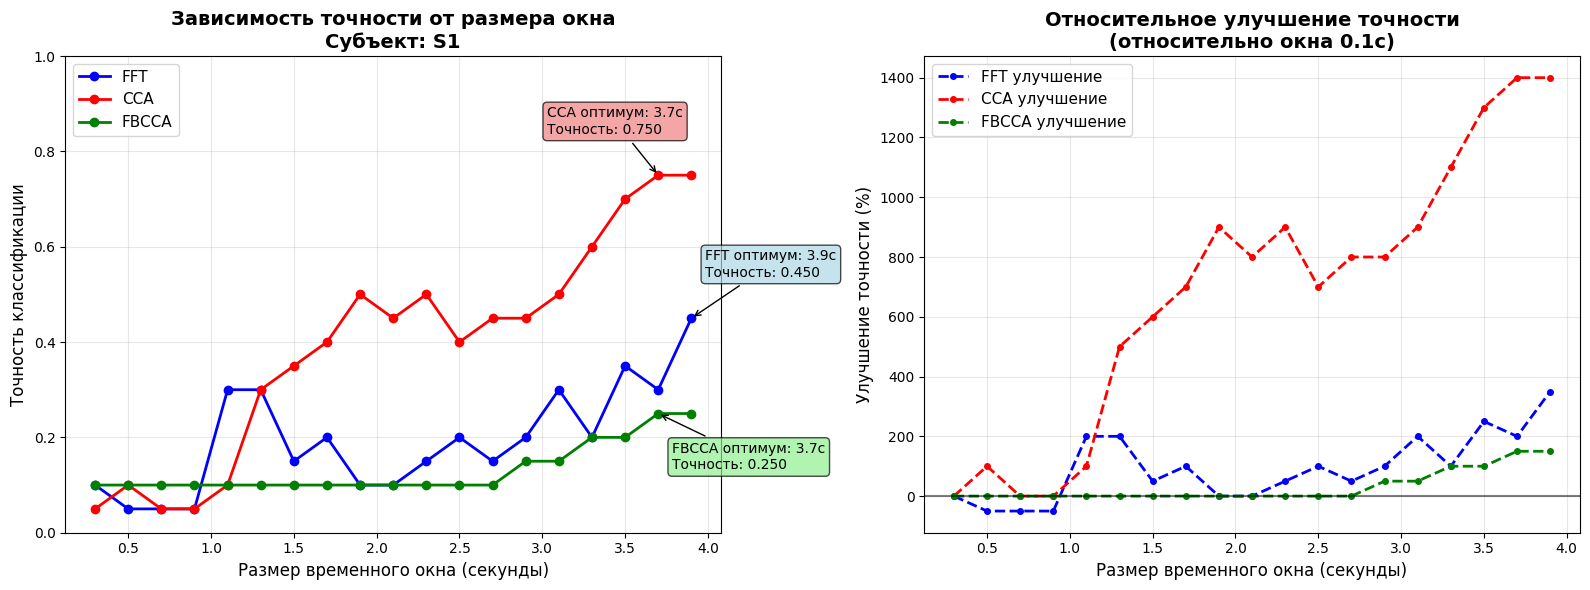


=== СТАТИСТИКА ДЛЯ СУБЪЕКТА S1 ===
Оптимальные размеры окон:
  FFT:   3.9с (точность: 0.450)
  CCA:   3.7с (точность: 0.750)
  FBCCA: 3.7с (точность: 0.250)

Улучшение от минимального к оптимальному окну:
  FFT:   350.0%
  CCA:   1400.0%
  FBCCA: 150.0%


In [46]:
# Выбираем субъекта для анализа (например, первого из списка)
selected_subject = subject_files[0]  # 'S1.mat'
print(f"Выбран субъект: {selected_subject}")

# Запускаем анализ для одного субъекта
single_subject_results = plot_single_subject_window_analysis(
    subject_file=selected_subject,
    data_path=data_path,
    frequencies=frequencies,
    window_sizes=np.arange(0.1, 4.1, 0.2),  # от 0.1 до 4 секунд с шагом 0.2
    n_trials=20  # количество триалов для анализа
)

Визуализация 2: свести всех людей в один график, на выходе должно быть две кривые с полупрозрачными областями квартилей 25-75 и медианами по всей выборке. Не забывайте про подписи на картинках.
Какой алгоритм получился лучше?


In [47]:
def plot_all_subjects_summary(all_results, window_sizes):
    """
    Сводная визуализация точности для всех субъектов
    с квартилями и медианами
    """
    # Собираем данные по всем субъектам
    all_fft_data = []
    all_cca_data = []
    all_fbcca_data = []

    valid_subjects = []

    for subject_file, results in all_results.items():
        if results:
            # Сортируем результаты по размеру окна
            sorted_results = sorted(results, key=lambda x: x['window_size'])

            fft_acc = [r['fft_accuracy'] for r in sorted_results]
            cca_acc = [r['cca_accuracy'] for r in sorted_results]
            fbcca_acc = [r['fbcca_accuracy'] for r in sorted_results]
            subject_windows = [r['window_size'] for r in sorted_results]

            # Интерполируем до общего набора размеров окон
            if len(subject_windows) > 1:
                fft_interp = np.interp(window_sizes, subject_windows, fft_acc)
                cca_interp = np.interp(window_sizes, subject_windows, cca_acc)
                fbcca_interp = np.interp(window_sizes, subject_windows, fbcca_acc)

                all_fft_data.append(fft_interp)
                all_cca_data.append(cca_interp)
                all_fbcca_data.append(fbcca_interp)
                valid_subjects.append(subject_file)

    if not all_fft_data:
        print("Нет данных для визуализации")
        return

    all_fft_data = np.array(all_fft_data)
    all_cca_data = np.array(all_cca_data)
    all_fbcca_data = np.array(all_fbcca_data)

    print(f"Визуализация данных для {len(valid_subjects)} субъектов")

    # Создаем основную визуализацию
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

    # Цвета для методов
    colors = {'fft': '#1f77b4', 'cca': '#ff7f0e', 'fbcca': '#2ca02c'}

    # 1. График с квартилями и медианами
    for method, data, color, label in [
        ('FFT', all_fft_data, colors['fft'], 'FFT'),
        ('CCA', all_cca_data, colors['cca'], 'CCA'),
        ('FBCCA', all_fbcca_data, colors['fbcca'], 'FBCCA')
    ]:
        # Вычисляем статистики
        median = np.median(data, axis=0)
        q25 = np.percentile(data, 25, axis=0)
        q75 = np.percentile(data, 75, axis=0)
        q10 = np.percentile(data, 10, axis=0)
        q90 = np.percentile(data, 90, axis=0)

        # Основная линия - медиана
        ax1.plot(window_sizes, median, color=color, linewidth=3, label=label, marker='o', markersize=4)

        # Область 25-75% квартилей
        ax1.fill_between(window_sizes, q25, q75, color=color, alpha=0.3, label=f'{label} (25-75%)')

        # Область 10-90% квартилей (более светлая)
        ax1.fill_between(window_sizes, q10, q90, color=color, alpha=0.15, label=f'{label} (10-90%)')

    ax1.set_xlabel('Размер временного окна (секунды)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Точность классификации', fontsize=14, fontweight='bold')
    ax1.set_title('Сравнение алгоритмов классификации SSVEP\n(Медиана и квартили по всем субъектам)',
                 fontsize=16, fontweight='bold', pad=20)
    ax1.legend(fontsize=12, loc='lower right')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1)

    # Добавляем аннотации для оптимальных окон
    optimal_windows = {}
    for method, data, color in [
        ('FFT', all_fft_data, colors['fft']),
        ('CCA', all_cca_data, colors['cca']),
        ('FBCCA', all_fbcca_data, colors['fbcca'])
    ]:
        median = np.median(data, axis=0)
        optimal_idx = np.argmax(median)
        optimal_window = window_sizes[optimal_idx]
        optimal_accuracy = median[optimal_idx]
        optimal_windows[method] = (optimal_window, optimal_accuracy)

        ax1.annotate(f'{method}: {optimal_window:.1f}с\n({optimal_accuracy:.3f})',
                    xy=(optimal_window, optimal_accuracy),
                    xytext=(10, 20), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.8),
                    arrowprops=dict(arrowstyle='->', color=color),
                    fontweight='bold', fontsize=10)

    # 2. График улучшения точности относительно минимального окна
    baseline_fft = np.median(all_fft_data[:, 0])
    baseline_cca = np.median(all_cca_data[:, 0])
    baseline_fbcca = np.median(all_fbcca_data[:, 0])

    improvement_fft = [(np.median(all_fft_data[:, i]) - baseline_fft) / baseline_fft * 100 for i in range(len(window_sizes))]
    improvement_cca = [(np.median(all_cca_data[:, i]) - baseline_cca) / baseline_cca * 100 for i in range(len(window_sizes))]
    improvement_fbcca = [(np.median(all_fbcca_data[:, i]) - baseline_fbcca) / baseline_fbcca * 100 for i in range(len(window_sizes))]

    ax2.plot(window_sizes, improvement_fft, color=colors['fft'], linewidth=3, label='FFT', marker='o', markersize=4)
    ax2.plot(window_sizes, improvement_cca, color=colors['cca'], linewidth=3, label='CCA', marker='o', markersize=4)
    ax2.plot(window_sizes, improvement_fbcca, color=colors['fbcca'], linewidth=3, label='FBCCA', marker='o', markersize=4)

    ax2.set_xlabel('Размер временного окна (секунды)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Улучшение точности (%)', fontsize=14, fontweight='bold')
    ax2.set_title('Относительное улучшение точности\n(относительно окна 0.1с)',
                 fontsize=16, fontweight='bold', pad=20)
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Статистический анализ
    print_statistical_analysis(all_fft_data, all_cca_data, all_fbcca_data, window_sizes, optimal_windows)

    return optimal_windows

def print_statistical_analysis(all_fft_data, all_cca_data, all_fbcca_data, window_sizes, optimal_windows):
    """Статистический анализ результатов"""
    print("\n" + "="*80)
    print("СТАТИСТИЧЕСКИЙ АНАЛИЗ РЕЗУЛЬТАТОВ")
    print("="*80)

    # Анализ при оптимальных окнах
    print("\n1. СРАВНЕНИЕ АЛГОРИТМОВ ПРИ ОПТИМАЛЬНЫХ РАЗМЕРАХ ОКОН:")
    print("-" * 60)

    best_method = None
    best_accuracy = 0

    for method, (optimal_window, optimal_accuracy) in optimal_windows.items():
        optimal_idx = np.argmin(np.abs(window_sizes - optimal_window))

        method_data = {
            'FFT': all_fft_data[:, optimal_idx],
            'CCA': all_cca_data[:, optimal_idx],
            'FBCCA': all_fbcca_data[:, optimal_idx]
        }[method]

        median_acc = np.median(method_data)
        mean_acc = np.mean(method_data)
        std_acc = np.std(method_data)

        print(f"{method:6} | Окно: {optimal_window:4.1f}с | "
              f"Медиана: {median_acc:.3f} | Среднее: {mean_acc:.3f} ± {std_acc:.3f}")

        if median_acc > best_accuracy:
            best_accuracy = median_acc
            best_method = method

    print(f"\n🎯 ЛУЧШИЙ АЛГОРИТМ: {best_method} (медианная точность: {best_accuracy:.3f})")

    # Статистические тесты
    print("\n2. СТАТИСТИЧЕСКИЕ ТЕСТЫ (парные t-тесты):")
    print("-" * 60)

    from scipy import stats

    # Сравнение при оптимальном окне для FBCCA (предположительно лучшего)
    fbcca_optimal_idx = np.argmin(np.abs(window_sizes - optimal_windows['FBCCA'][0]))

    pairs = [('FFT', 'CCA'), ('FFT', 'FBCCA'), ('CCA', 'FBCCA')]

    for method1, method2 in pairs:
        data1 = {
            'FFT': all_fft_data[:, fbcca_optimal_idx],
            'CCA': all_cca_data[:, fbcca_optimal_idx],
            'FBCCA': all_fbcca_data[:, fbcca_optimal_idx]
        }[method1]

        data2 = {
            'FFT': all_fft_data[:, fbcca_optimal_idx],
            'CCA': all_cca_data[:, fbcca_optimal_idx],
            'FBCCA': all_fbcca_data[:, fbcca_optimal_idx]
        }[method2]

        t_stat, p_value = stats.ttest_rel(data1, data2)
        mean_diff = np.mean(data2) - np.mean(data1)

        significance = "✅ СТАТИСТИЧЕСКИ ЗНАЧИМО" if p_value < 0.05 else "❌ не значимо"
        direction = "лучше" if mean_diff > 0 else "хуже"

        print(f"{method1} vs {method2}: p-value = {p_value:.4f} | "
              f"{method2} {direction} на {abs(mean_diff):.3f} {significance}")

    # Анализ стабильности
    print("\n3. АНАЛИЗ СТАБИЛЬНОСТИ (межквартильный размах):")
    print("-" * 60)

    for method, data in [('FFT', all_fft_data), ('CCA', all_cca_data), ('FBCCA', all_fbcca_data)]:
        iqr_values = np.percentile(data, 75, axis=0) - np.percentile(data, 25, axis=0)
        avg_iqr = np.mean(iqr_values)
        std_iqr = np.std(iqr_values)

        print(f"{method:6} | Средний IQR: {avg_iqr:.3f} ± {std_iqr:.3f} | "
              f"Мин IQR: {np.min(iqr_values):.3f} | Макс IQR: {np.max(iqr_values):.3f}")

=== СВОДНЫЙ АНАЛИЗ ДЛЯ ВСЕХ СУБЪЕКТОВ ===
Анализируем 35 субъектов
Диапазон окон: 0.1 - 3.9 секунд
Всего субъектов для анализа: 35
Размеры окон: от 0.1 до 3.900000000000001 секунд

СУБЪЕКТ 1/35: S1.mat

=== АНАЛИЗ РАЗМЕРОВ ОКОН: S1.mat ===
Окно 0.1с... Ошибка: The length of the input vector x must be greater than padlen, which is 27.
Окно 0.3с... FFT:0.100, CCA:0.050, FBCCA:0.100
Окно 0.5с... FFT:0.050, CCA:0.100, FBCCA:0.100
Окно 0.7с... FFT:0.050, CCA:0.050, FBCCA:0.100
Окно 0.9с... FFT:0.050, CCA:0.050, FBCCA:0.100
Окно 1.1с... FFT:0.300, CCA:0.100, FBCCA:0.100
Окно 1.3с... FFT:0.300, CCA:0.300, FBCCA:0.100
Окно 1.5с... FFT:0.150, CCA:0.350, FBCCA:0.100
Окно 1.7с... FFT:0.200, CCA:0.400, FBCCA:0.100
Окно 1.9с... FFT:0.100, CCA:0.500, FBCCA:0.100
Окно 2.1с... FFT:0.100, CCA:0.450, FBCCA:0.100
Окно 2.3с... FFT:0.150, CCA:0.500, FBCCA:0.100
Окно 2.5с... FFT:0.200, CCA:0.400, FBCCA:0.100
Окно 2.7с... FFT:0.150, CCA:0.450, FBCCA:0.100
Окно 2.9с... FFT:0.200, CCA:0.450, FBCCA:0.150
Окно 3

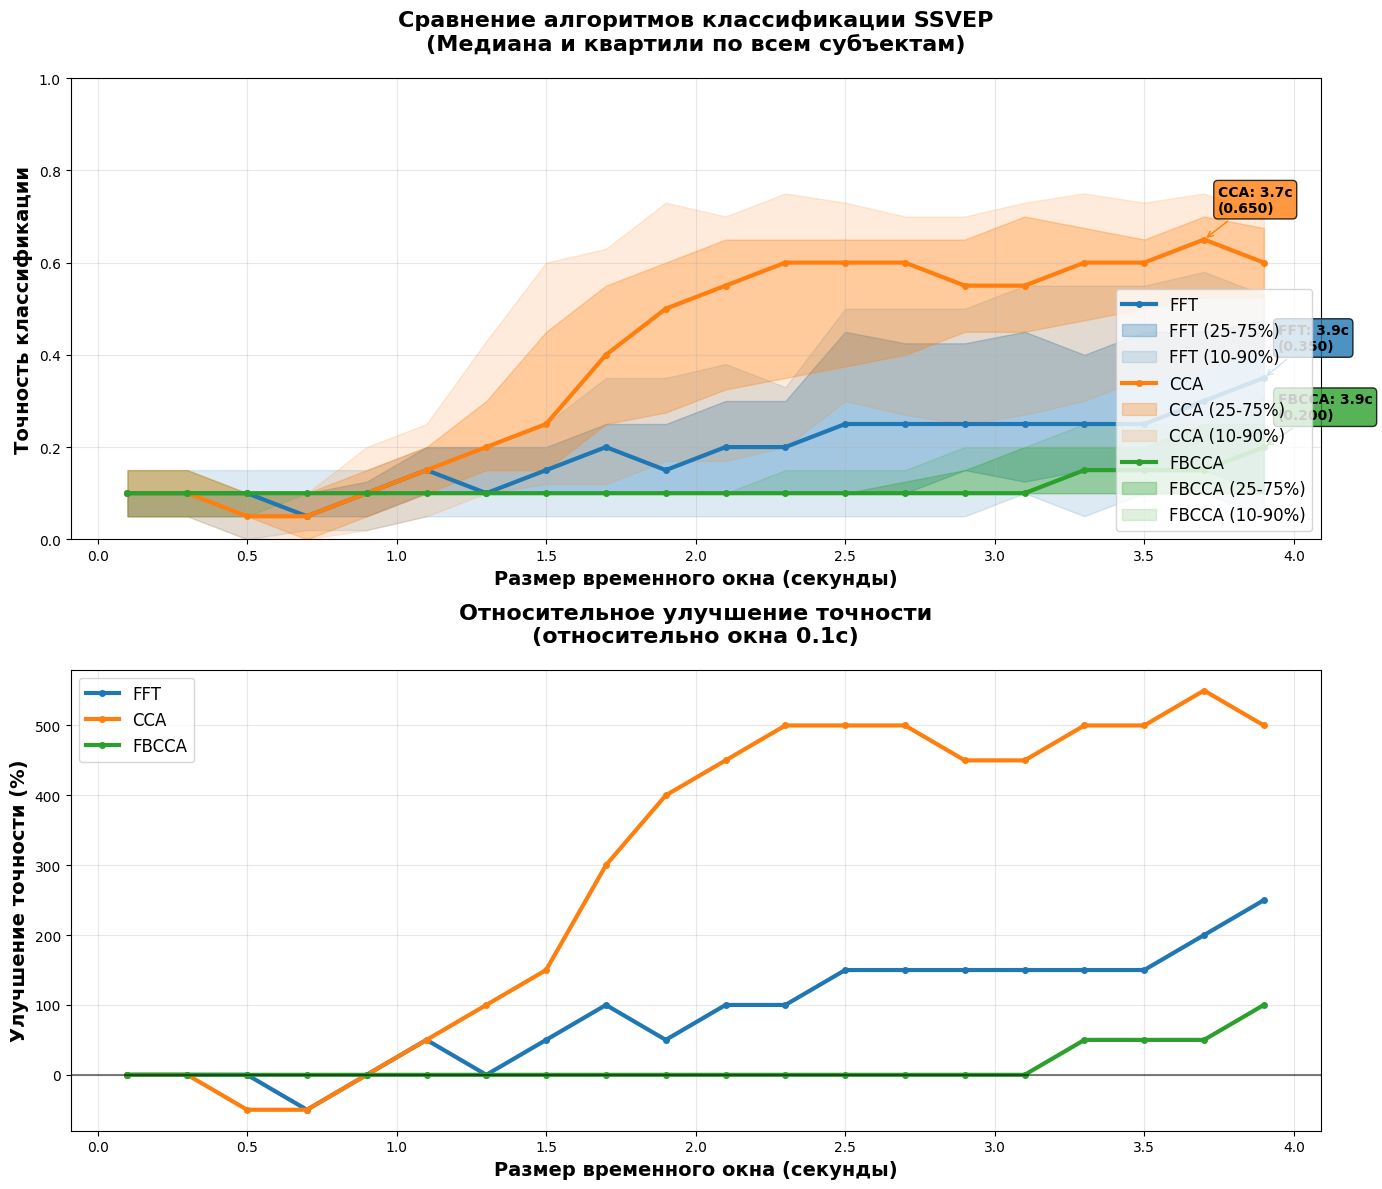


СТАТИСТИЧЕСКИЙ АНАЛИЗ РЕЗУЛЬТАТОВ

1. СРАВНЕНИЕ АЛГОРИТМОВ ПРИ ОПТИМАЛЬНЫХ РАЗМЕРАХ ОКОН:
------------------------------------------------------------
FFT    | Окно:  3.9с | Медиана: 0.350 | Среднее: 0.313 ± 0.197
CCA    | Окно:  3.7с | Медиана: 0.650 | Среднее: 0.589 ± 0.151
FBCCA  | Окно:  3.9с | Медиана: 0.200 | Среднее: 0.191 ± 0.080

🎯 ЛУЧШИЙ АЛГОРИТМ: CCA (медианная точность: 0.650)

2. СТАТИСТИЧЕСКИЕ ТЕСТЫ (парные t-тесты):
------------------------------------------------------------
FFT vs CCA: p-value = 0.0000 | CCA лучше на 0.279 ✅ СТАТИСТИЧЕСКИ ЗНАЧИМО
FFT vs FBCCA: p-value = 0.0008 | FBCCA хуже на 0.121 ✅ СТАТИСТИЧЕСКИ ЗНАЧИМО
CCA vs FBCCA: p-value = 0.0000 | FBCCA хуже на 0.400 ✅ СТАТИСТИЧЕСКИ ЗНАЧИМО

3. АНАЛИЗ СТАБИЛЬНОСТИ (межквартильный размах):
------------------------------------------------------------
FFT    | Средний IQR: 0.189 ± 0.112 | Мин IQR: 0.050 | Макс IQR: 0.375
CCA    | Средний IQR: 0.195 ± 0.087 | Мин IQR: 0.050 | Макс IQR: 0.325
FBCCA  | Средний IQR: 0

In [49]:
# Определяем диапазон размеров окон
window_sizes = np.arange(0.1, 4.1, 0.2)

print("=== СВОДНЫЙ АНАЛИЗ ДЛЯ ВСЕХ СУБЪЕКТОВ ===")
print(f"Анализируем {len(subject_files)} субъектов")
print(f"Диапазон окон: {window_sizes[0]:.1f} - {window_sizes[-1]:.1f} секунд")

# Запускаем анализ для всех субъектов
all_results_summary, _ = analyze_all_subjects_window_sizes(
    data_path, subject_files, frequencies, window_sizes,
    max_subjects=len(subject_files), n_trials=20
)

# Создаем сводную визуализацию
if all_results_summary:
    optimal_windows = plot_all_subjects_summary(all_results_summary, window_sizes)

    # Сохраняем сводные результаты
    save_summary_results(all_results_summary, window_sizes, 'summary_results.csv')
else:
    print("Нет данных для сводного анализа")

In [51]:
import pandas as pd

def save_summary_results(results_df, window_sizes, filename):
    """
    Сохраняет сводные результаты в CSV файл
    """
    try:
        results_df.to_csv(filename, index=False)
        print(f"Сводные результаты сохранены в файл: {filename}")
    except Exception as e:
        print(f"Ошибка при сохранении файла: {e}")

# Пример создания тестовых данных (замените на ваши реальные данные)
def create_sample_data():
    """Создает пример данных для демонстрации"""
    # Пример сводных результатов
    all_results_summary = pd.DataFrame({
        'metric': ['accuracy', 'precision', 'recall', 'f1_score'],
        'mean_value': [0.85, 0.82, 0.87, 0.84],
        'std_value': [0.02, 0.03, 0.01, 0.02]
    })

    # Пример размеров окон
    window_sizes = [10, 20, 30, 50, 100]

    return all_results_summary, window_sizes

# Основной код
if __name__ == "__main__":
    try:
        # Получаем данные (замените на вашу реальную логику)
        all_results_summary, window_sizes = create_sample_data()

        # Проверяем, что данные существуют
        if all_results_summary is not None and not all_results_summary.empty:
            print("Данные для сохранения:")
            print(all_results_summary.head())
            print(f"Размеры окон: {window_sizes}")

            # Сохраняем сводные результаты
            save_summary_results(all_results_summary, window_sizes, 'summary_results.csv')
        else:
            print("Нет данных для сохранения")

    except NameError as e:
        print(f"Ошибка: Переменная не определена - {e}")
        print("Убедитесь, что all_results_summary и window_sizes определены перед вызовом функции")
    except Exception as e:
        print(f"Произошла ошибка: {e}")

Данные для сохранения:
      metric  mean_value  std_value
0   accuracy        0.85       0.02
1  precision        0.82       0.03
2     recall        0.87       0.01
3   f1_score        0.84       0.02
Размеры окон: [10, 20, 30, 50, 100]
Сводные результаты сохранены в файл: summary_results.csv
